In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.api import OLS, add_constant
import glob
import os
import itertools
import dateutil.relativedelta as rd

In [185]:
START_DAY = '2024-12-01'
END_DAY = '2025-12-01'
DATA_SAVE_DIR = 'Data'
RISK_FREE_RATE = 0.03
INITIAL_CAPITAL = 10000


# i addes more coins to download data for simnce some of top 50 coins are not available on yahoo finance or binance
# but i wanst sure to do this, so i disabled it and not use it, but i wanted to keep it to show that i thought about it
USE_MORE_COINS = False

In [186]:
np.random.seed(15206)

## These are the codes Dr.Entezari shared in the class. 

In [187]:
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    return result[1] 

In [188]:
def hurst_exponent(series, q=2.0, max_lag=None, min_lag=2):

    series = np.asarray(series, dtype=float)
    n = len(series)

    if max_lag is None:
        max_lag = n // 4
    if max_lag <= min_lag:
        raise ValueError("max_lag must be > min_lag")

    # Lags
    lags = np.arange(min_lag, max_lag)

    # K_q values for each lag
    K = np.zeros_like(lags, dtype=float)

    for i, lag in enumerate(lags):
        diffs = np.abs(series[lag:] - series[:-lag])
        K[i] = np.mean(diffs ** q)

    # Fit log–log to estimate slope
    log_lags = np.log(lags)
    log_K = np.log(K)

    slope, _ = np.polyfit(log_lags, log_K, 1)

    H = slope / q

    
    return H

In [189]:
def half_life(series):    
    series = series.dropna()
    
    # Create lagged series
    price_lag = series.shift(1)
    price_diff = series - price_lag
    
    # Remove NaN values
    valid_data = pd.concat([price_lag, price_diff], axis=1).dropna()
    price_lag_clean = valid_data.iloc[:, 0]
    price_diff_clean = valid_data.iloc[:, 1]
    
    # Add constant for regression
    X = add_constant(price_lag_clean)
    
    # Perform OLS regression
    try:
        model = OLS(price_diff_clean, X)
        results = model.fit()
        beta = float(results.params.iloc[1]) if len(results.params) > 1 else 0.0
        
        # Calculate half-life
        half_life = -np.log(2) / np.log(1 + beta) if (1 + beta) > 0 else np.nan
        print('Half-life: %0.2f' % half_life)
        return half_life
    except:
        return np.nan
    

In [190]:
def johansen_test(data):
    arr = np.asarray(data)
    # statsmodels expects data with shape (T, N)
    result = coint_johansen(arr, det_order=0, k_ar_diff=1)

    # Johansen trace statistic for rank=0
    trace0 = result.lr1[0]
    # 95% critical value (if available)
    cv95 = result.cvt[0, 1] if result.cvt.shape[1] > 1 else np.nan
    is_cointegrated = trace0 > cv95

    # pick the first cointegrating vector column
    vec = result.evec[:, 0]
    return result, is_cointegrated, vec, trace0, cv95


## Part 0: Downloading the coins dataset

In [ ]:
import time
import requests
import yfinance as yf
from datetime import datetime, timezone 


OUT_DIR = os.path.join(os.getcwd(), DATA_SAVE_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

COINS = [
    ("BTC","Bitcoin"), ("ETH","Ethereum"), ("USDT","Tether"), ("BNB","BNB"),
    ("XRP","XRP"), ("USDC","USDC"), ("SOL","Solana"), ("TRX","TRON"),
    ("DOGE","Dogecoin"), ("ADA","Cardano"), ("BCH","Bitcoin Cash"), ("HYPE","Hyperliquid"),
    ("LINK","Chainlink"), ("LEO","UNUS SED LEO"), ("XMR","Monero"), ("XLM","Stellar"),
    ("ZEC","Zeash"), ("USDe","Ethena USDe"), ("LTC","Litecoin"), ("SUI","Sui"),
    ("DAI","Dai"), ("AVAX","Avalanche"), ("HBAR","Hedera"), ("SHIB","Shiba Inu"),
    ("MNT","Mantle"), ("PYUSD","PayPal USD"), ("TON","Toncoin"), ("WLFI","World Liberty Financial"),
    ("CRO","Cronos"), ("UNI","Uniswap"), ("DOT","Polkadot"), ("TAO","Bitensor"),
    ("AAVE","Aave"), ("USD1","World Liberty Financial USD"), ("CC","Canton"), ("BGB","Bitget Token"),
    ("OKB","OKB"), ("M","MemeCore"), ("ASTER","Aster"), ("NEAR","NEAR Protocol"),
    ("ETC","Ethereum Classic"), ("PEPE","Pepe"), ("ENA","Ethena"), ("ICP","Internet Computer"),
    ("PI","Pi"), ("XAUt","Tether Gold"), ("PAXG","PAX Gold"), ("USDG","Global Dollar"),
    ("KCS","KuCoin Token"), ("WLD","Worldcoin"),
]

# top 50 above are not all downladed from yahoo finance or binance so i added some more coins after top 50 to cover it
EXTRA_COINS = [
    ("RLUSD", "Ripple USD"), ("SKY", "Sky"), ("APT", "Aptos"), ("KAS", "Kaspa"),
    ("ONDO", "Ondo"), ("POL", "Polygon"), ("ARB", "Arbitrum"), ("ALGO", "Algorand"),
    ("TRUMP", "OFFICIAL TRUMP"), ("MYX", "MYX Finance"), ("XDC", "XDC Network"),
    ("ATOM", "Cosmos"),
]

if USE_MORE_COINS:
    ALL_COINS = COINS + [c for c in EXTRA_COINS if c[0] not in [x[0] for x in COINS]]
else:
    ALL_COINS = COINS

def yahoo_ticker_for(symbol):
    return f"{symbol.upper()}-USD"

def download_from_yahoo(symbol):
    ticker = yahoo_ticker_for(symbol)
    t = yf.Ticker(ticker)
    try:
        end_incl = (pd.to_datetime(END_DAY) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    except Exception:
        end_incl = END_DAY
    
    df = t.history(start=START_DAY, end=end_incl, interval='1d', auto_adjust=False)
    
    if df is None or df.empty:
        ticker2 = f"{symbol.upper()}-USDT"
        t2 = yf.Ticker(ticker2)
        df2 = t2.history(start=START_DAY, end=end_incl, interval='1d', auto_adjust=False)
        return df2
    return df

def download_from_binance(symbol):
    sym = f"{symbol.upper()}USDT"
    start_dt = datetime.strptime(START_DAY, "%Y-%m-%d")
    end_dt = datetime.strptime(END_DAY, "%Y-%m-%d")
    start_ms = int(start_dt.replace(tzinfo=None).timestamp() * 1000)
    end_ms = int(end_dt.replace(tzinfo=None).timestamp() * 1000)
    
    url = (
        f"https://api.binance.com/api/v3/klines?symbol={sym}&interval=1d&startTime={start_ms}&endTime={end_ms}&limit=1000"
    )
    
    try:
        r = requests.get(url, timeout=30)
    except Exception:
        return None

    if r.status_code != 200:
        return None
    data = r.json()
    if not data or not isinstance(data, list):
        return None
    
    rows = []
    for k in data:
        open_time = int(k[0])
        date = datetime.fromtimestamp(open_time/1000.0, timezone.utc).date()
        rows.append({
            'Date': date,
            'Open': float(k[1]),
            'High': float(k[2]),
            'Low': float(k[3]),
            'Close': float(k[4]),
            'Volume': float(k[5]),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.set_index(pd.to_datetime(df['Date']))
        df.index.name = None
        df = df.drop(columns=['Date'])
    return df

def save_df_csv(symbol, df):
    fname = os.path.join(OUT_DIR, f"{symbol}_1D.csv")
    if not df.empty:
        df = df.copy()
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        
        if 'Date' not in df.columns:
            df.insert(0, 'Date', df.index.date)
            
        cols = list(df.columns)
        df.to_csv(fname, index=False, columns=cols)
    return fname

def download_coins():
    success = []
    failed = []
    
    required_rows = 365 
    
    for symbol, name in ALL_COINS:
        print(f"Processing {symbol} ({name})...")
        ticker = yahoo_ticker_for(symbol)
        
        try:
            df = download_from_yahoo(symbol)
            used_source = 'yahoo'

            if df is None or df.empty or len(df) < required_rows:
                df_b = download_from_binance(symbol)
                if df_b is not None and not df_b.empty:
                    if df is None or len(df_b) > len(df):
                        df = df_b
                        used_source = 'binance'

            if df is None or df.empty:
                print(f"  -> No data found for {symbol}")
                failed.append((symbol, name, "No Data"))
            elif len(df) < required_rows:
                print(f"  -> Failed: Only {len(df)} rows (Requires {required_rows})")
                failed.append((symbol, name, f"Insufficient Data: {len(df)} rows"))
            else:
                fname = save_df_csv(symbol, df) 
                print(f"  -> Saved via {used_source}")
                success.append((symbol, ticker, used_source))
                
        except Exception as e:
            print(f"  -> Error for {symbol}: {e}")
            failed.append((symbol, name, str(e)))
        
        time.sleep(0.3)


    print(f"\n{len(success)} Succeeded, {len(failed)} Failed")
    
    print("SUCCESSFUL:")
    for s in success:
        print(f"   [+] {s[0]} ({s[2]})")
        
    print("\nFAILED:")
    for f in failed:
        print(f"   [-] {f[0]}: {f[2]}")


In [192]:
download_coins()

Processing BTC (Bitcoin)...
  -> Saved via yahoo
Processing ETH (Ethereum)...
  -> Saved via yahoo
Processing USDT (Tether)...
  -> Saved via yahoo
Processing BNB (BNB)...
  -> Saved via yahoo
Processing XRP (XRP)...
  -> Saved via yahoo
Processing USDC (USDC)...
  -> Saved via yahoo
Processing SOL (Solana)...
  -> Saved via yahoo
Processing TRX (TRON)...
  -> Saved via yahoo
Processing DOGE (Dogecoin)...
  -> Saved via yahoo
Processing ADA (Cardano)...
  -> Saved via yahoo
Processing BCH (Bitcoin Cash)...
  -> Saved via yahoo


$HYPE-USD: possibly delisted; no price data found  (1d 2024-12-01 -> 2025-12-02)
$HYPE-USDT: possibly delisted; no timezone found


Processing HYPE (Hyperliquid)...
  -> No data found for HYPE
Processing LINK (Chainlink)...
  -> Saved via yahoo
Processing LEO (UNUS SED LEO)...
  -> Saved via yahoo
Processing XMR (Monero)...
  -> Saved via yahoo
Processing XLM (Stellar)...
  -> Saved via yahoo
Processing ZEC (Zeash)...
  -> Saved via yahoo
Processing USDe (Ethena USDe)...
  -> Failed: Only 83 rows (Requires 365)
Processing LTC (Litecoin)...
  -> Saved via yahoo


$SUI-USD: possibly delisted; no price data found  (1d 2024-12-01 -> 2025-12-02)
$SUI-USDT: possibly delisted; no timezone found


Processing SUI (Sui)...
  -> Saved via binance
Processing DAI (Dai)...
  -> Saved via yahoo
Processing AVAX (Avalanche)...
  -> Saved via yahoo
Processing HBAR (Hedera)...
  -> Saved via yahoo
Processing SHIB (Shiba Inu)...
  -> Saved via yahoo


...

Processing TAO (Bitensor)...
  -> Saved via binance
Processing AAVE (Aave)...
  -> Saved via yahoo
Processing USD1 (World Liberty Financial USD)...
  -> Failed: Only 193 rows (Requires 365)


$CC-USD: possibly delisted; no price data found  (1d 2024-12-01 -> 2025-12-02)
$CC-USDT: possibly delisted; no timezone found


Processing CC (Canton)...
  -> No data found for CC
Processing BGB (Bitget Token)...
  -> Saved via yahoo
Processing OKB (OKB)...
  -> Saved via yahoo
Processing M (MemeCore)...
  -> Saved via yahoo
Processing ASTER (Aster)...
  -> Failed: Only 265 rows (Requires 365)
Processing NEAR (NEAR Protocol)...
  -> Saved via yahoo
Processing ETC (Ethereum Classic)...
  -> Saved via yahoo


$PEPE-USD: possibly delisted; no price data found  (1d 2024-12-01 -> 2025-12-02)
$PEPE-USDT: possibly delisted; no timezone found


Processing PEPE (Pepe)...
  -> Saved via binance
Processing ENA (Ethena)...
  -> Saved via yahoo
Processing ICP (Internet Computer)...
  -> Saved via yahoo
Processing PI (Pi)...
  -> Failed: Only 131 rows (Requires 365)
Processing XAUt (Tether Gold)...
  -> Saved via yahoo
Processing PAXG (PAX Gold)...
  -> Saved via yahoo
Processing USDG (Global Dollar)...
  -> Saved via yahoo
Processing KCS (KuCoin Token)...
  -> Saved via yahoo
Processing WLD (Worldcoin)...
  -> Saved via yahoo

42 Succeeded, 8 Failed
SUCCESSFUL:
   [+] BTC (yahoo)
   [+] ETH (yahoo)
   [+] USDT (yahoo)
   [+] BNB (yahoo)
   [+] XRP (yahoo)
   [+] USDC (yahoo)
   [+] SOL (yahoo)
   [+] TRX (yahoo)
   [+] DOGE (yahoo)
   [+] ADA (yahoo)
   [+] BCH (yahoo)
   [+] LINK (yahoo)
   [+] LEO (yahoo)
   [+] XMR (yahoo)
   [+] XLM (yahoo)
   [+] ZEC (yahoo)
   [+] LTC (yahoo)
   [+] SUI (binance)
   [+] DAI (yahoo)
   [+] AVAX (yahoo)
   [+] HBAR (yahoo)
   [+] SHIB (yahoo)
   [+] PYUSD (yahoo)
   [+] TON (yahoo)
   [+] CRO 

## Part 1

In [193]:
def run_adf_on_data(data_dir=DATA_SAVE_DIR, alpha=0.05, start_day=None, end_day=None):
    files = sorted(glob.glob(os.path.join(data_dir, '*_1D.csv')))
    results = []
    for f in files:
        name = os.path.basename(f).replace('_1D.csv', '')

        df = pd.read_csv(f, index_col=0, parse_dates=True)

        series = df['Close'].dropna()
        try:
            if start_day is not None or end_day is not None:
                series = series.loc[start_day:end_day]
        except Exception:
            continue

        if len(series) < 10:
            continue
        try:
            res = adfuller(series)
            pval = float(res[1])
            results.append((name, pval, len(series)))
        except Exception:
            continue

    stationary = [r for r in results if r[1] <= alpha]

    if stationary:
        print(f"\nStable coins (p-value) in the period from {start_day} to {end_day}:")
        for name, pval, n in sorted(stationary, key=lambda x: x[1]):
            print(f"{name}: {pval:.6f}")
    else:
        print('No stationary coins found in the specified period and daily timeframe.')


    return results, [r[0] for r in stationary]


In [194]:
def plot_candlestick(df, title):
    dates = df.index.to_pydatetime()
    if len(dates) == 0:
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    dnum = mdates.date2num(dates)

    if len(dnum) > 1:
        width = (dnum[1] - dnum[0]) * 0.6
    else:
        width = 0.6

    for i, t in enumerate(dnum):
        openp = df['Open'].iloc[i]
        highp = df['High'].iloc[i]
        lowp = df['Low'].iloc[i]
        closep = df['Close'].iloc[i]

        lower_body = min(openp, closep)
        upper_body = max(openp, closep)
        color = '#26a69a' if closep >= openp else '#ef5350'

        if lowp < lower_body:
            ax.plot([t, t], [lowp, lower_body], color='k', linewidth=0.5)
        if highp > upper_body:
            ax.plot([t, t], [upper_body, highp], color='k', linewidth=0.5)

        y_range = df['High'].max() - df['Low'].min()
        min_height = (y_range * 1e-4) if (y_range and y_range > 0) else 1e-6
        height = max(upper_body - lower_body, min_height)
        rect = patches.Rectangle((t - width / 2, lower_body), width, height,
                     facecolor=color, edgecolor=color, linewidth=0.6)
        ax.add_patch(rect)

    ax.xaxis_date()
    ax.set_title(title)
    ax.set_ylabel('Price')
    fig.autofmt_xdate()

    plt.show()

In [195]:
results_part1, stationary_names_part1 = run_adf_on_data(data_dir=DATA_SAVE_DIR, alpha=0.05, start_day=START_DAY, end_day=END_DAY)


Stable coins (p-value) in the period from 2024-12-01 to 2025-12-01:
PYUSD: 0.000000
DAI: 0.000000
DOT: 0.000150
ZEC: 0.000327
USDT: 0.000996
USDC: 0.007032
WLD: 0.015210
NEAR: 0.016447
TAO: 0.019186
XLM: 0.027161
ICP: 0.028728
BGB: 0.029622
SHIB: 0.030948
LTC: 0.047629
XRP: 0.048759


## Part 2

In [196]:
def compute_metrics_for_coin(filepath):
    name = os.path.basename(filepath).replace('_1D.csv', '')

    df = pd.read_csv(filepath, index_col=0, parse_dates=True)

    req_cols = ['Open', 'High', 'Low', 'Close']
    if not all(c in df.columns for c in req_cols):
        return name, np.nan, np.nan, None

    series = df['Close'].dropna()

    series = series.loc[START_DAY:END_DAY]

    if len(series) < 10:
        print( f"not enough data for {name} in the specified period." )
        return name, np.nan, np.nan, None

    hl = half_life(series)
    H = hurst_exponent(series)
    return name, hl, H, df.loc[series.index]


### ۵. توضیح دهید توان Hurst و نیمه‌عمر چه چیزی درباره سری‌های قیمتی بیان می‌کنند.

- **توان هرست (H):** این معیار به ما می‌گوید که رفتار یک سری زمانی (مانند اسپرد قیمت) چگونه است:
    
    - **H<0.5:** سری **بازگشت به میانگین** (Mean-Reverting) است. یعنی اگر قیمت بالا برود، احتمالا دوباره پایین می‌آید (مناسب برای جفت‌ارزها)
        
    - **H=0.5:** سری **گام تصادفی** (Random Walk) است. حرکت بعدی قابل پیش‌بینی نیست
        
    - **H>0.5:** سری **رونددار** (Trending) است. یعنی اگر قیمت بالا برود، تمایل دارد به بالا رفتن ادامه دهد


- **نیمه‌عمر (Half-Life):** این معیار نشان می‌دهد چقدر طول می‌کشد تا سری پس از دور شدن از میانگین، نیمی از مسیر بازگشت را طی کند.
    
    - **نیمه‌عمر کوتاه:** اسپرد سریع به میانگین برمی‌گردد (فرصت‌های معاملاتی بیشتر، ریسک کمتر).
        
    - **نیمه‌عمر طولانی:** زمان زیادی طول می‌کشد تا قیمت برگردد (فرصت کمتر، ریسک خواب سرمایه).


In [197]:
def analyze_stationary_and_plot(data_dir=DATA_SAVE_DIR, alpha=0.05, start_day=None, end_day=None):
    results, stationary_names = run_adf_on_data(data_dir=data_dir, alpha=alpha, start_day=start_day, end_day=end_day)
    if not stationary_names:
        print("no coin is stationary.")
        return []

    files = sorted(glob.glob(os.path.join(data_dir, '*_1D.csv')))
    metrics = []
    for f in files:
        name = os.path.basename(f).replace('_1D.csv', '')
        if name not in stationary_names:
            continue
        n, hl, H, df = compute_metrics_for_coin(f)
        metrics.append((n, hl, H, df, f))

    metrics_sorted = sorted(metrics, key=lambda x: (np.inf if (x[1] is None or np.isnan(x[1])) else x[1]))

    print("\nHurst and Half-life for the stationary coins:")
    for name, hl, H, df, fpath in metrics_sorted:
        print(f"{name}: Half-life = {hl if not np.isnan(hl) else 'NaN'}, Hurst = {H if not np.isnan(H) else 'NaN'}")
        if df is not None:
            plot_candlestick(df[['Open', 'High', 'Low', 'Close']], f"{name} candlestick")

    return metrics_sorted


Stable coins (p-value) in the period from 2024-12-01 to 2025-12-01:
PYUSD: 0.000000
DAI: 0.000000
DOT: 0.000150
ZEC: 0.000327
USDT: 0.000996
USDC: 0.007032
WLD: 0.015210
NEAR: 0.016447
TAO: 0.019186
XLM: 0.027161
ICP: 0.028728
BGB: 0.029622
SHIB: 0.030948
LTC: 0.047629
XRP: 0.048759
Half-life: 18.45
Half-life: 0.70
Half-life: 33.98
Half-life: 34.47
Half-life: 14.20
Half-life: 33.87
Half-life: 0.68
Half-life: 24.72
Half-life: 16.51
Half-life: 0.49
Half-life: 2.50
Half-life: 24.39
Half-life: 19.02
Half-life: 14.62
Half-life: 177.23

Hurst and Half-life for the stationary coins:
USDC: Half-life = 0.49002097330883576, Hurst = 0.00879617208278388


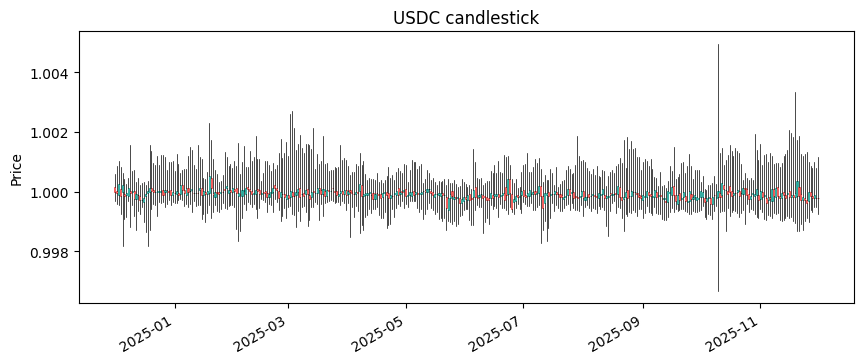

PYUSD: Half-life = 0.677141552902625, Hurst = 0.00016118583541869488


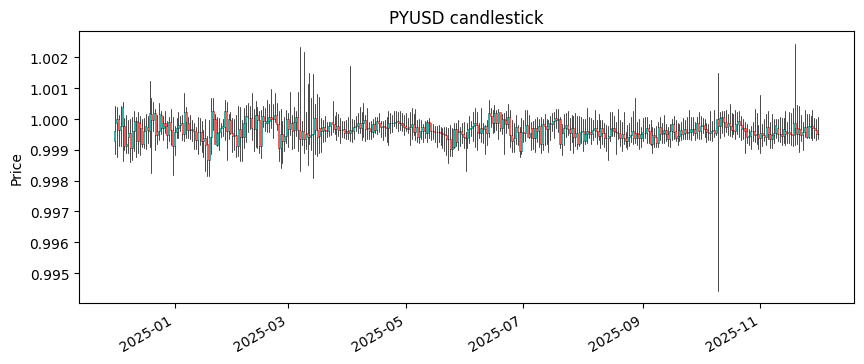

DAI: Half-life = 0.7029473751707094, Hurst = 0.017483863649204682


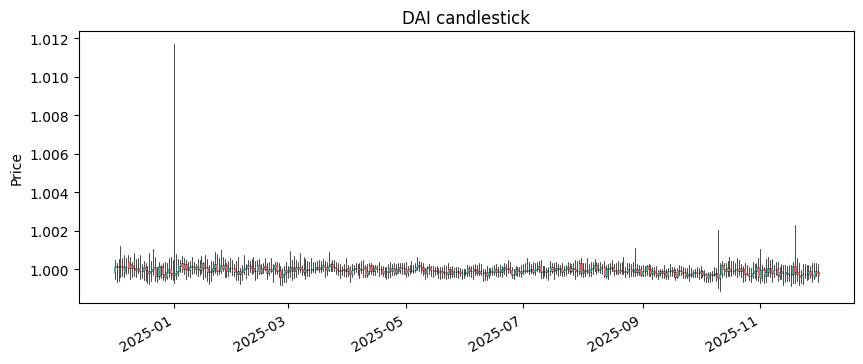

USDT: Half-life = 2.4971314634727246, Hurst = 0.05235273557286184


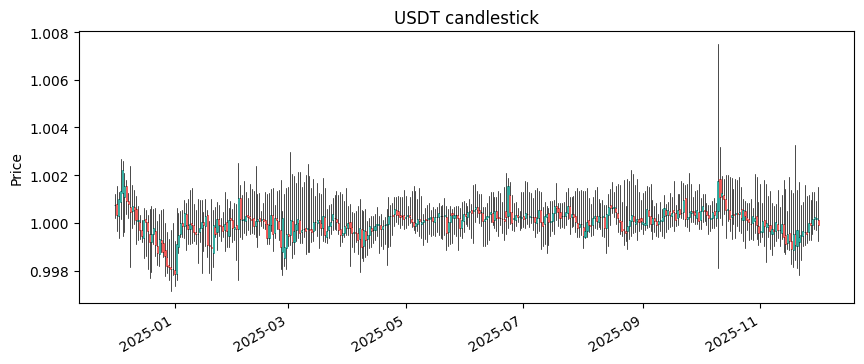

LTC: Half-life = 14.20008999009672, Hurst = 0.3310673298675484


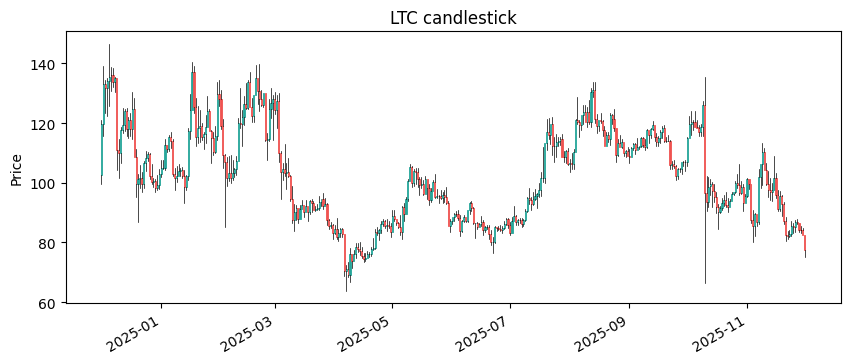

XRP: Half-life = 14.621571996324002, Hurst = 0.3445531400563806


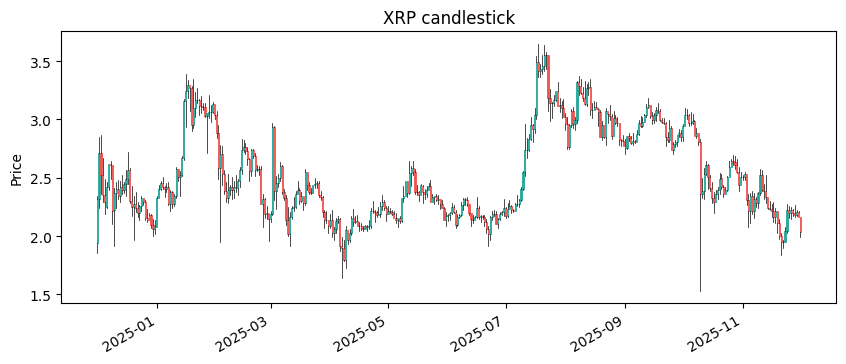

TAO: Half-life = 16.51188997232602, Hurst = 0.36801382481133943


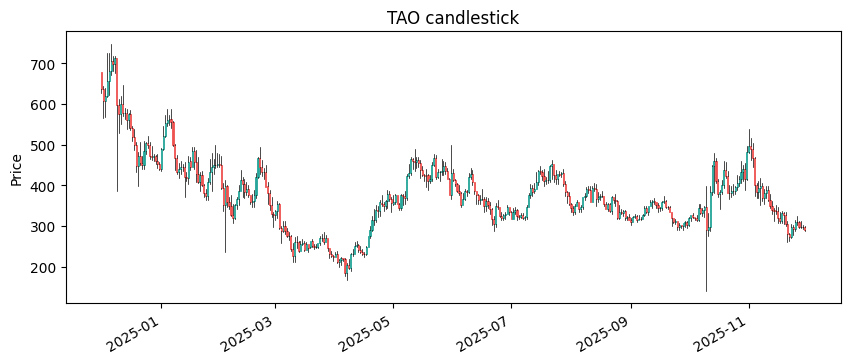

BGB: Half-life = 18.45333957796632, Hurst = 0.30669478076542717


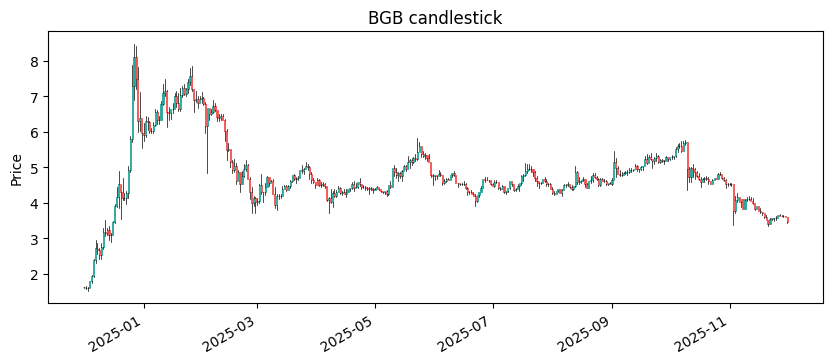

XLM: Half-life = 19.02471653971783, Hurst = 0.4112772632936967


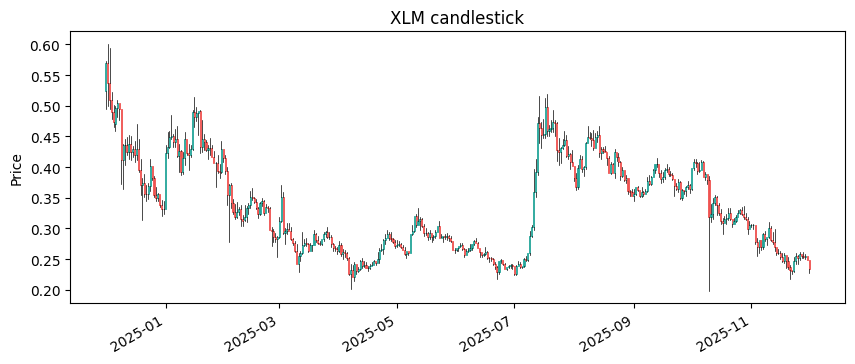

WLD: Half-life = 24.38860168848602, Hurst = 0.48163691606470604


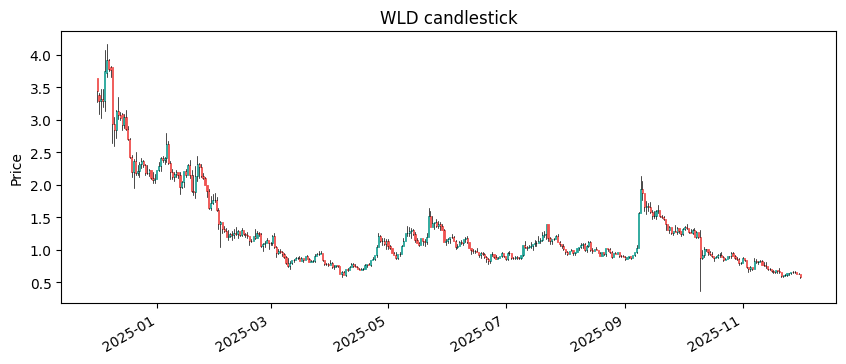

SHIB: Half-life = 24.72334971805541, Hurst = 0.4975599858091532


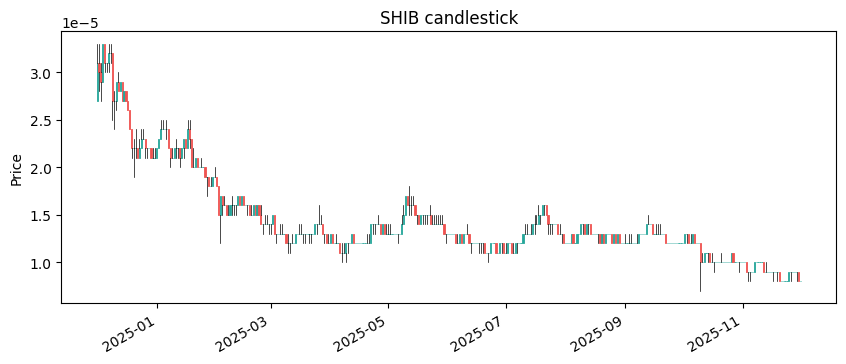

NEAR: Half-life = 33.86831700126915, Hurst = 0.4884906141417959


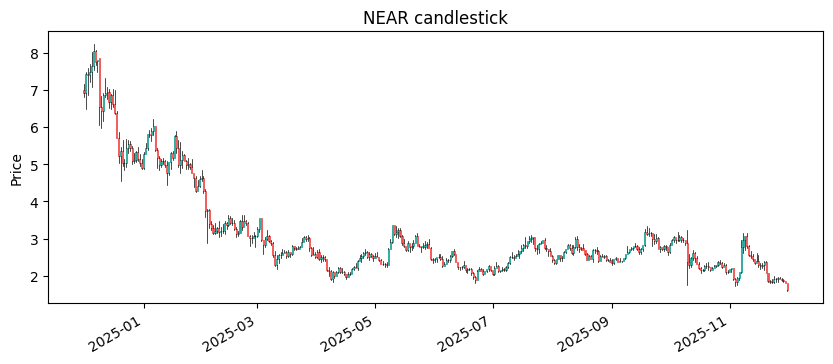

DOT: Half-life = 33.97703723992067, Hurst = 0.4619522527185471


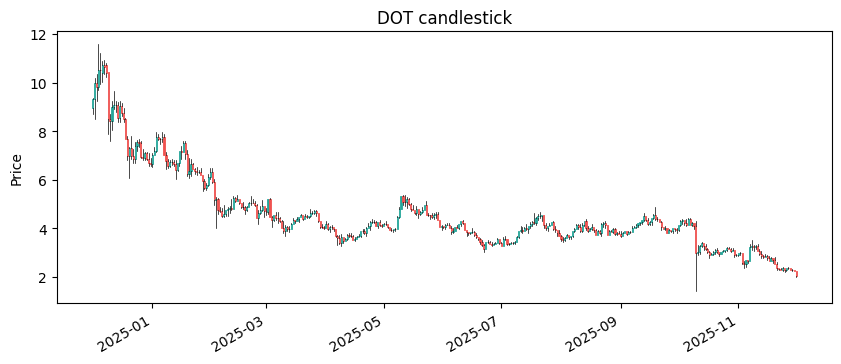

ICP: Half-life = 34.472790348806015, Hurst = 0.4287746107357628


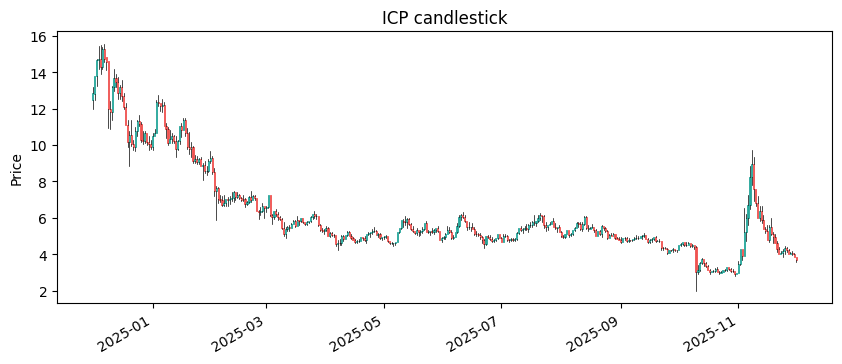

ZEC: Half-life = 177.22590624037056, Hurst = 0.5530480924206759


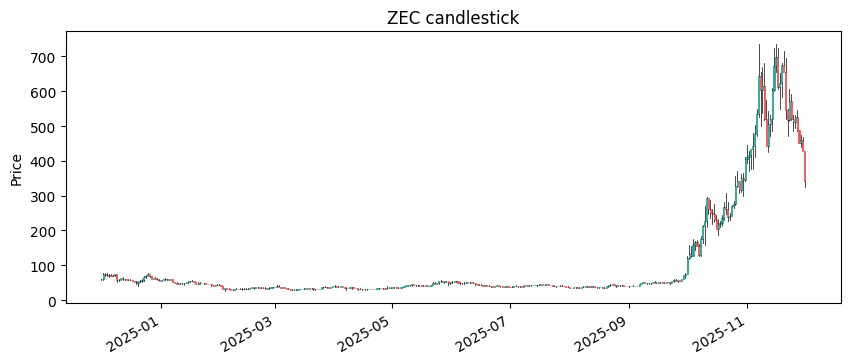

In [198]:
metrics = analyze_stationary_and_plot(data_dir=DATA_SAVE_DIR, alpha=0.05, start_day=START_DAY, end_day=END_DAY)

## Part 3

In [199]:
def prepare_candidates(data_dir, alpha, start_day, end_day):
    results, stationary_names = run_adf_on_data(data_dir=data_dir, alpha=alpha, start_day=start_day, end_day=end_day)
    nonstationary = [name for name, p, n in results if name not in stationary_names]
    files_map = {os.path.basename(p).replace('_1D.csv', ''): p for p in sorted(glob.glob(os.path.join(data_dir, '*_1D.csv')))}
    return nonstationary, files_map


def load_and_align_combo(combo, files_map, start_day, end_day):
    dfs = []
    
    for name in combo:
        path = files_map.get(name)
        if path is None:
            return None
            
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        if start_day is not None or end_day is not None:
            df = df.loc[start_day:end_day]
            
        if len(df) < 10:
            return None
            
        dfs.append(df[['Open', 'High', 'Low', 'Close']].copy())

    idx = dfs[0].index
    for d in dfs[1:]:
        idx = idx.intersection(d.index)
        
    if len(idx) < 10:
        return None

    closes = np.column_stack([d.loc[idx, 'Close'].values for d in dfs])
    return dfs, idx, closes



In [200]:
def check_cointegration(closes, combo, tested_count):
    res, is_coint, vec, trace0, cv95 = johansen_test(closes)

    cv95_v1 = cv95
    cv95_v2 = np.nan
    
    if tested_count <= 5:
        print(f"  Combo {combo}: trace0={trace0:.2f}, cv95[0,1]={cv95_v1 if not np.isnan(cv95_v1) else float('nan'):.2f}, cv95[0,2]={cv95_v2 if not np.isnan(cv95_v2) else float('nan'):.2f}, pass={is_coint}")

    return is_coint, vec, trace0, cv95


def calculate_spread_metrics(closes, vec, idx):
    spread = closes.dot(vec)
    
    adf_p = perform_adf_test(spread)

    spread_series = pd.Series(spread, index=idx)

    hl = half_life(spread_series)
    try:
        H = hurst_exponent(spread_series.values)
    except Exception:
        H = np.nan
        
    return spread, {'adf_p': adf_p, 'hl': hl, 'hurst': H}



def build_synthetic_ohlc(dfs, idx, vec, closes_mat):
    opens = np.column_stack([d.loc[idx, 'Open'].values for d in dfs])
    highs = np.column_stack([d.loc[idx, 'High'].values for d in dfs])
    lows = np.column_stack([d.loc[idx, 'Low'].values for d in dfs])

    spread_ohlc = pd.DataFrame(index=idx)
    spread_ohlc['Open'] = opens.dot(vec)
    spread_ohlc['Close'] = closes_mat.dot(vec)

    high_contrib = np.zeros_like(highs[:, 0], dtype=float)
    low_contrib = np.zeros_like(lows[:, 0], dtype=float)
    
    for j, w in enumerate(vec):
        if w >= 0:
            high_contrib += w * highs[:, j]
            low_contrib += w * lows[:, j]
        else:
            high_contrib += w * lows[:, j]
            low_contrib += w * highs[:, j]

    spread_ohlc['High'] = high_contrib
    spread_ohlc['Low'] = low_contrib
    
    return spread_ohlc


def print_final_summary(tested, found):
    print(f'\nTested {tested} combos, found {len(found)} cointegrated.')
    print('\nAll found combos and their half-life values:')
    for i, f in enumerate(found):
        print(f"  {i+1}. {f['names']}: hl={f['hl']}, adf_p={f['adf_p']:.6f}")

In [201]:
def find_linear_stationary_combinations(data_dir=DATA_SAVE_DIR, alpha=0.05, target=10, max_size=10, start_day=None, end_day=None , shuffle=False):
    nonstationary, files_map = prepare_candidates(data_dir, alpha, start_day, end_day)
    
    excluded_coins = {'TON', 'USDT', 'USDC', 'DAI', 'PYUSD', 'USDG', 'USD1', 'PAXG', 'XAUt'}
    
    found = []
    tested = 0

    if shuffle:
        np.random.shuffle(nonstationary)

    for size in range(3, max_size + 1):
        if len(found) >= target:
            break
            
        for combo in itertools.combinations(nonstationary, size):
            if len(found) >= target:
                break

            if any(c.upper() in excluded_coins for c in combo):
                continue

            aligned_data = load_and_align_combo(combo, files_map, start_day, end_day)
            if not aligned_data:
                continue
            
            dfs, idx, closes = aligned_data
            tested += 1

            coint_res = check_cointegration(closes, combo, tested)
            if not coint_res:
                continue
            
            is_coint, vec, trace0, cv95 = coint_res
            if not is_coint:
                continue

            spread, metrics = calculate_spread_metrics(closes, vec, idx)

            spread_ohlc = build_synthetic_ohlc(dfs, idx, vec, closes)

            result_entry = {
                'names': list(combo),
                'vec': vec,
                'trace0': trace0,
                'trace0_cv95': cv95,
                'adf_p': metrics['adf_p'],
                'hl': metrics['hl'],
                'hurst': metrics['hurst'],
                'spread_ohlc': spread_ohlc,
                'constituent_ohlc': {name: dfs[i].loc[idx].copy() for i, name in enumerate(combo)}
            }
            found.append(result_entry)

    print_final_summary(tested, found)
    return found

In [202]:
def select_top5_and_plot(found):
    if not found:
        print("no cointegrated combos found.")
        return []
    
    filtered = [f for f in found if f['hl'] is not None and not np.isnan(f['hl'])]

    top5 = sorted(filtered, key=lambda x: x['hl'])[:5]

    for item in top5:
        names = item['names']
        print(f"\nCombo: {names}  Half-life: {item["hl"]}  ADF_p(spread): {item["adf_p"]}")

        n = len(names)
        fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3 * n), sharex=True)
        if n == 1:
            axes = [axes]
        for ax, name in zip(axes, names):
            df = item['constituent_ohlc'][name].copy()

            first_close = df['Close'].iloc[0]
            df_norm = df[['Open', 'High', 'Low', 'Close']] / first_close


            dnum = [pd.Timestamp(i).to_pydatetime() for i in df_norm.index]
            dnum = mdates.date2num(dnum)
            if len(dnum) > 1:
                width = (dnum[1] - dnum[0]) * 0.6
            else:
                width = 0.6
            for i, t in enumerate(dnum):
                o = df_norm['Open'].iloc[i]
                h = df_norm['High'].iloc[i]
                l = df_norm['Low'].iloc[i]
                c = df_norm['Close'].iloc[i]
                lower_body = min(o, c)
                upper_body = max(o, c)
                color = '#26a69a' if c >= o else '#ef5350'

                wick_color = color
                if l < lower_body:
                    ax.plot([t, t], [l, lower_body], color=wick_color, linewidth=0.5, zorder=1)
                if h > upper_body:
                    ax.plot([t, t], [upper_body, h], color=wick_color, linewidth=0.5, zorder=1)
                y_range_norm = df_norm['High'].max() - df_norm['Low'].min()
                min_h = (y_range_norm * 1e-4) if (y_range_norm and y_range_norm > 0) else 1e-6
                body_h = max(1e-6, upper_body - lower_body)
                height = max(body_h, min_h)

                rect = patches.Rectangle((t - width / 2, lower_body), width, height, facecolor=color, edgecolor=color, linewidth=0.6, zorder=3)
                ax.add_patch(rect)
            ax.xaxis_date()
            ax.set_ylabel(name)
        fig.suptitle('Normalized constituents for {}'.format(','.join(names)))
        fig.autofmt_xdate()
        plt.show()

        spread_df = item['spread_ohlc']
        plot_candlestick(spread_df[['Open', 'High', 'Low', 'Close']], f"Spread for {','.join(names)}")

    return top5




Stable coins (p-value) in the period from None to None:
PYUSD: 0.000000
DAI: 0.000000
DOT: 0.000150
ZEC: 0.000327
USDT: 0.000996
USDC: 0.007032
WLD: 0.015210
NEAR: 0.016447
TAO: 0.019186
XLM: 0.027161
ICP: 0.028728
BGB: 0.029622
SHIB: 0.030948
LTC: 0.047629
XRP: 0.048759
  Combo ('AAVE', 'ADA', 'AVAX'): trace0=38.03, cv95[0,1]=29.80, cv95[0,2]=nan, pass=True
ADF Statistic: -4.376937
p-value: 0.000326
Half-life: 25.34
  Combo ('AAVE', 'ADA', 'BCH'): trace0=29.08, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
  Combo ('AAVE', 'ADA', 'BNB'): trace0=26.57, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
  Combo ('AAVE', 'ADA', 'BTC'): trace0=27.79, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
  Combo ('AAVE', 'ADA', 'CRO'): trace0=23.80, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
ADF Statistic: -3.707954
p-value: 0.004003
Half-life: 6.85
ADF Statistic: -6.008956
p-value: 0.000000
Half-life: 15.32
ADF Statistic: -4.364626
p-value: 0.000343
Half-life: 4.36
ADF Statistic: -4.169257
p-value: 0.000742
H

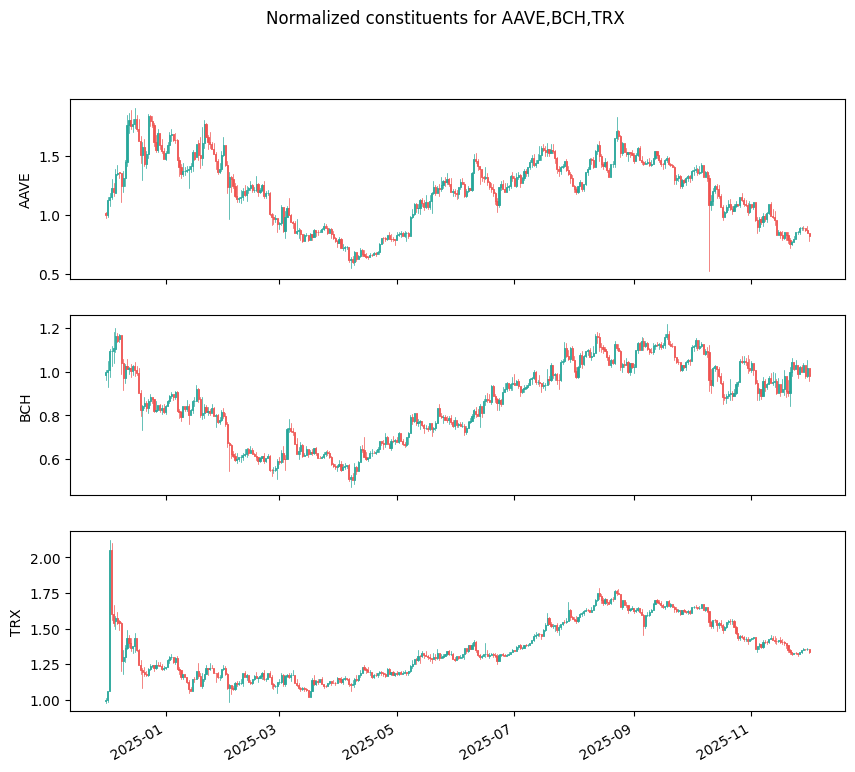

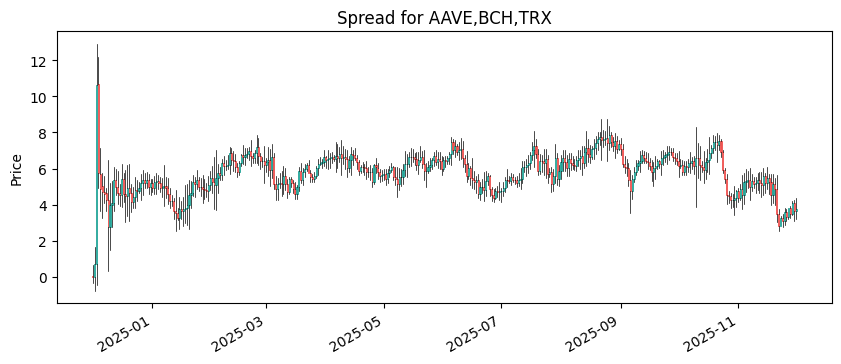


Combo: ['AAVE', 'ETH', 'TRX']  Half-life: 3.104878719187505  ADF_p(spread): 6.035022211865028e-10


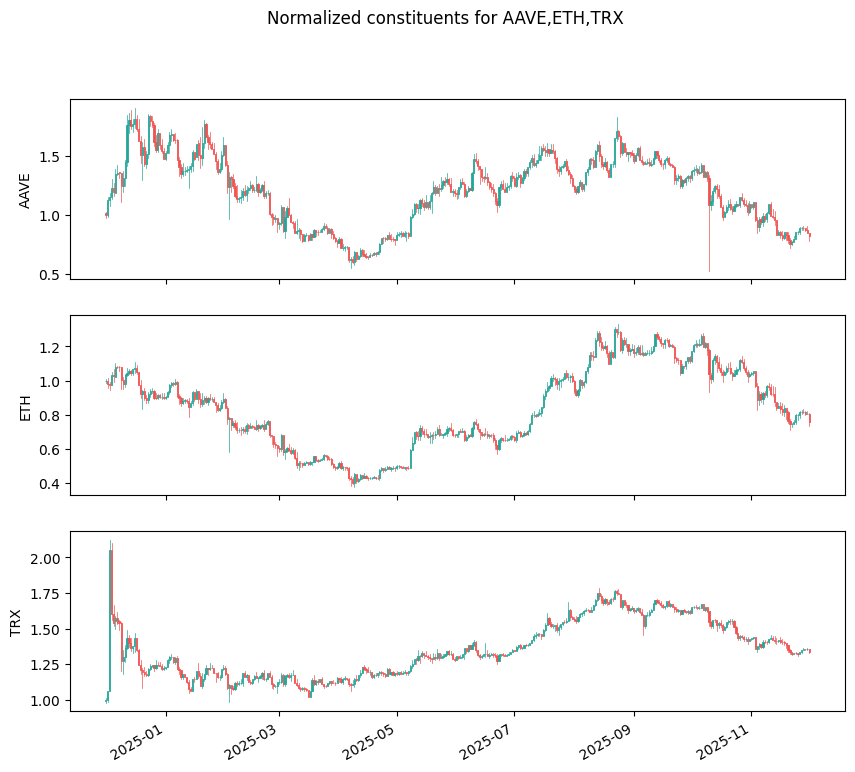

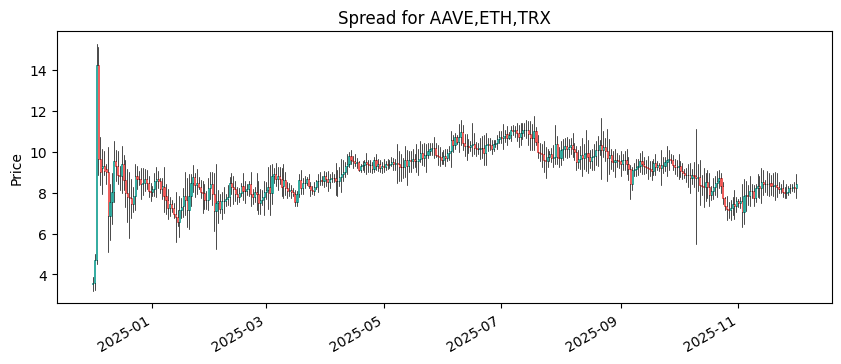


Combo: ['AAVE', 'BTC', 'TRX']  Half-life: 3.7485591740955666  ADF_p(spread): 2.699368278530423e-07


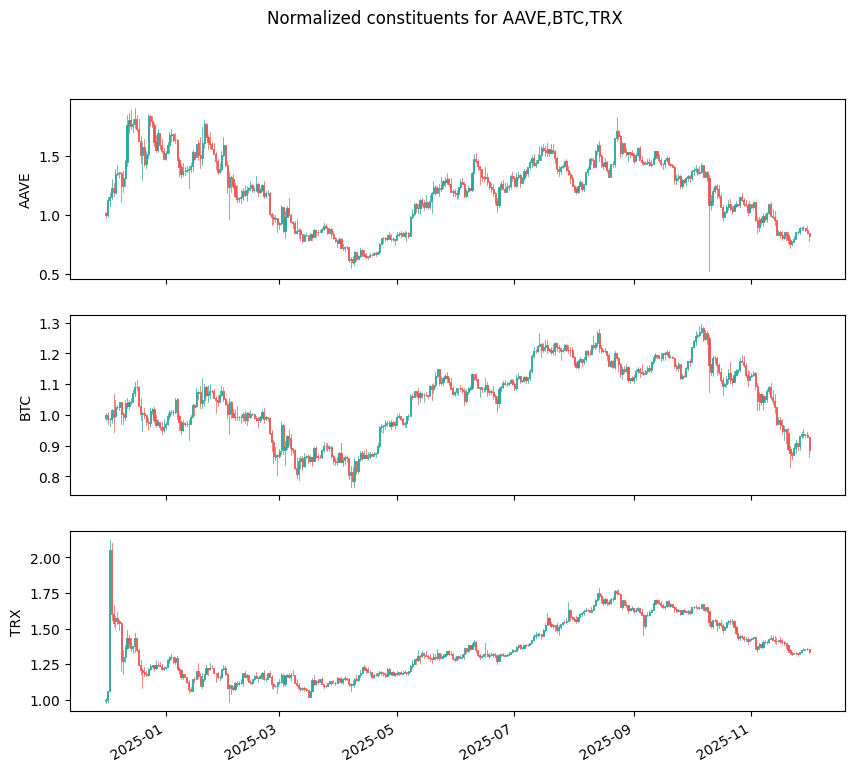

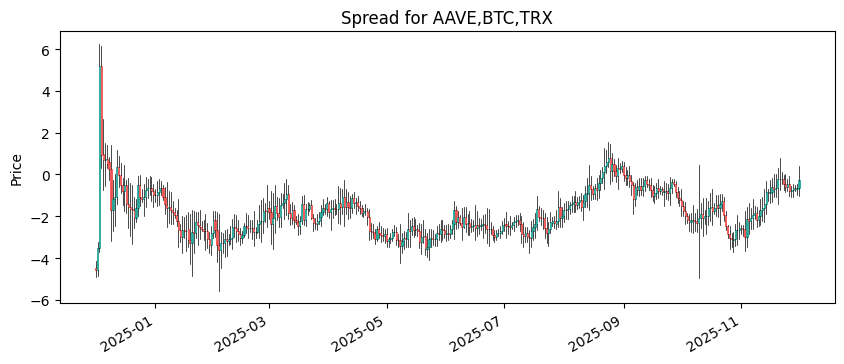


Combo: ['ADA', 'BCH', 'HBAR']  Half-life: 3.868017211148099  ADF_p(spread): 0.0003312103955940768


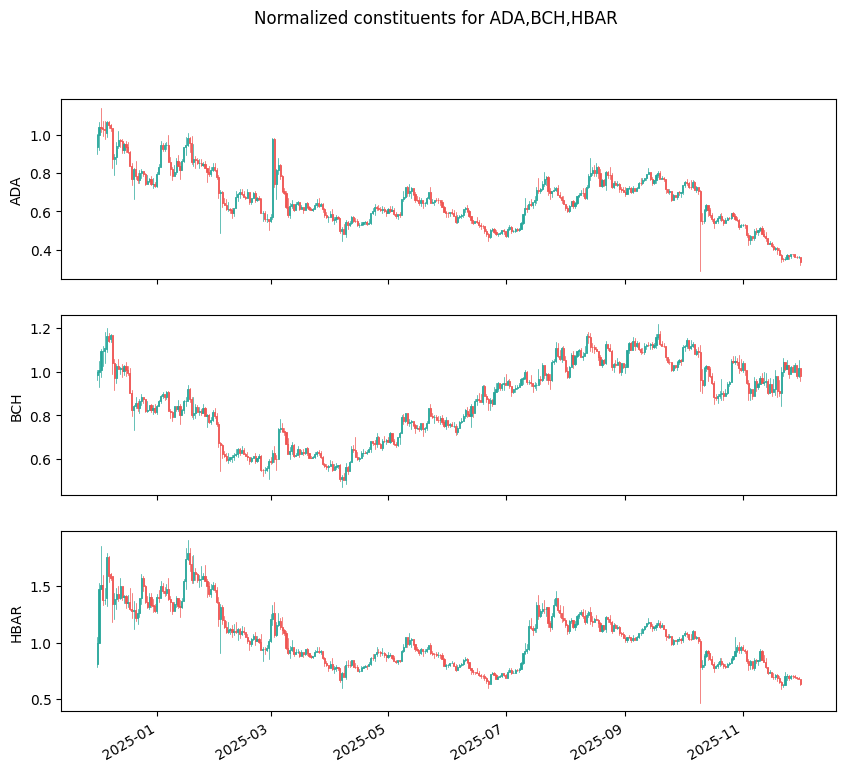

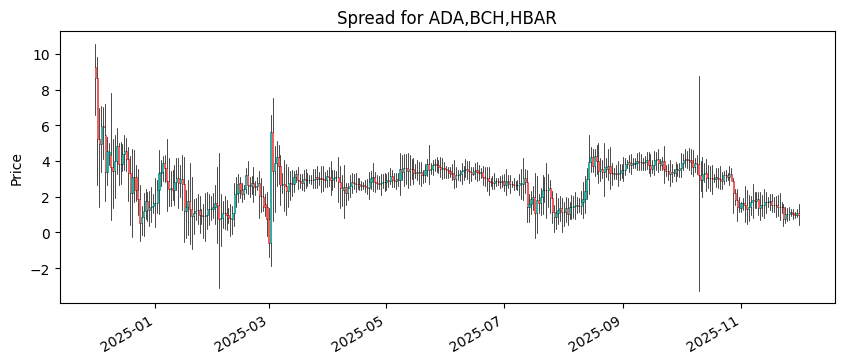


Combo: ['ADA', 'AVAX', 'HBAR']  Half-life: 4.253419383794519  ADF_p(spread): 0.0004313932994140519


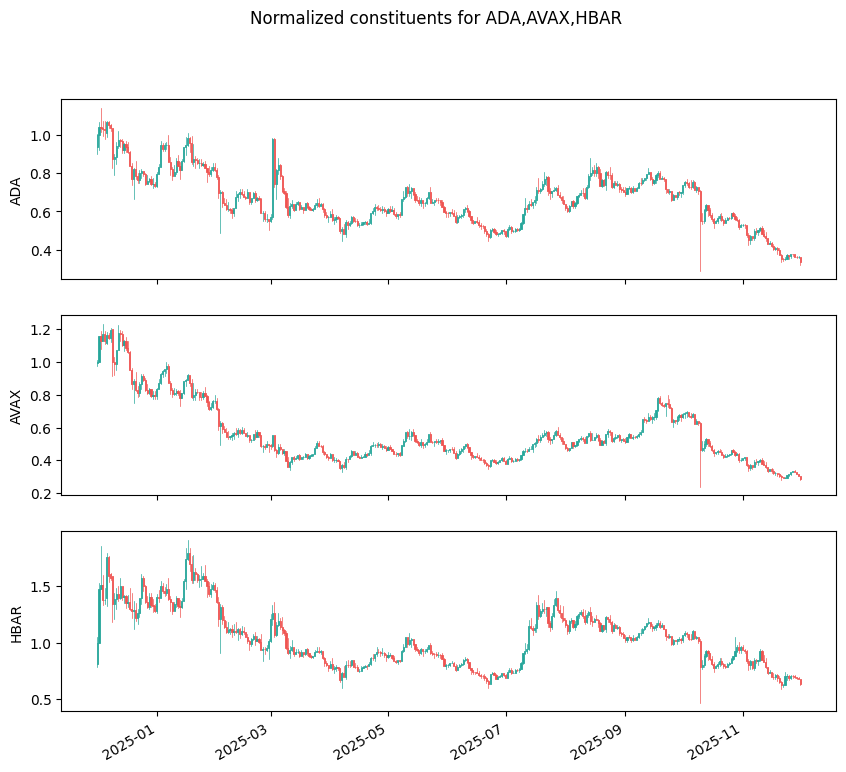

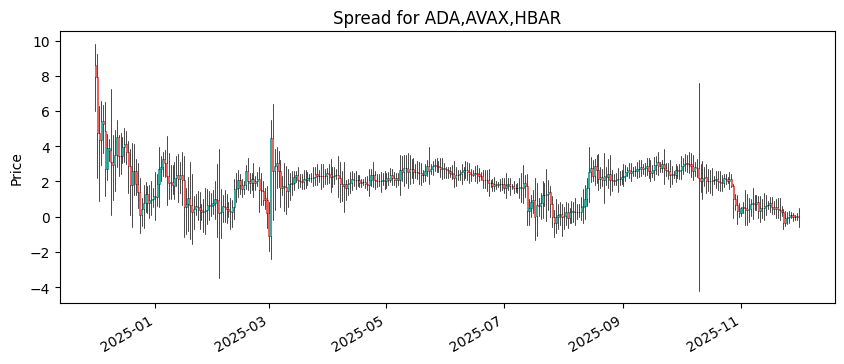

In [203]:
founds = find_linear_stationary_combinations(data_dir=DATA_SAVE_DIR, alpha=0.05, target=100, max_size=4)
topp_five = select_top5_and_plot(founds)

## Part 4

In [204]:
def calculate_indicators(spread_ohlc, hl):
    if hl < 30:
        lookback = int(np.ceil(30 / hl) * hl)
    else:
        lookback = int(2 * hl)
    
    hl_diff = spread_ohlc['High'] - spread_ohlc['Low']
    ema = hl_diff.ewm(span=lookback, adjust=False).mean()
    std = spread_ohlc['Close'].rolling(window=lookback).std()
    
    return ema, std, lookback

In [205]:
def run_simulation_loop(spread_ohlc, ema, std, start_idx, initial_capital):
    capital = initial_capital
    position = 0  
    position_value = 0 
    entry_price = 0
    trades = []
    equity_curve = []
    is_bankrupt = False
    
    for i in range(start_idx, len(spread_ohlc)):
        current_date = spread_ohlc.index[i]
        high = spread_ohlc['High'].iloc[i]
        low = spread_ohlc['Low'].iloc[i]
        close = spread_ohlc['Close'].iloc[i]
        current_ema = ema.iloc[i]
        current_std = std.iloc[i]
        
        if np.isnan(current_ema) or np.isnan(current_std):
            continue
        
        upper_1std = current_ema + current_std
        upper_2std = current_ema + 2 * current_std
        lower_1std = current_ema - current_std
        lower_2std = current_ema - 2 * current_std
        
        # --- 1. Calculate Current Portfolio Equity ---
        if position > 0:
            current_value = capital + position * close
        elif position < 0:
            current_value = capital + position_value + (-position) * (entry_price - close)
        else:
            current_value = capital
        
        # --- 2. Bankruptcy Check ---
        if current_value <= 0:
            print(f"You are BANKRUPT at {current_date.date()} - Equity hit ${current_value:.2f} !!!")
            if position != 0:
                pnl = position * (close - entry_price) if position > 0 else -position * (entry_price - close)
                trades.append({'date': current_date, 'action': 'LIQUIDATION', 'position': position, 'price': close, 'pnl': pnl, 'capital': 0})
            
            capital = 0
            equity_curve.append({'date': current_date, 'equity': 0})
            is_bankrupt = True
            break 
            
        equity_curve.append({'date': current_date, 'equity': current_value})
        
        # --- 3. Exit Logic ---
        if position != 0:
            if (position > 0 and close >= current_ema) or (position < 0 and close <= current_ema):
                pnl = position * (close - entry_price) if position > 0 else -position * (entry_price - close)
                capital += position_value + pnl
                trades.append({'date': current_date, 'action': 'EXIT', 'position': position, 'price': close, 'pnl': pnl, 'capital': capital})
                position = 0
                position_value = 0
                entry_price = 0
                
                if capital <= 0:
                    print(f"  !!! CAPITAL DEPLETED at {current_date.date()} !!!")
                    is_bankrupt = True
                    break

        # --- 4. Entry Logic ---
        if position == 0 and capital > 0:
            # Level 1 Entries
            if low < lower_1std: # Long 1
                entry_amount = min(capital * 0.5, capital)
                if entry_amount > 0:
                    position = entry_amount / close
                    position_value = entry_amount
                    entry_price = close
                    capital -= entry_amount
                    trades.append({'date': current_date, 'action': 'LONG_1', 'position': position, 'price': close, 'amount': entry_amount, 'capital': capital})
            elif high > upper_1std: # Short 1
                entry_amount = min(capital * 0.5, capital)
                if entry_amount > 0:
                    position = -(entry_amount / close)
                    position_value = entry_amount
                    entry_price = close
                    capital -= entry_amount
                    trades.append({'date': current_date, 'action': 'SHORT_1', 'position': position, 'price': close, 'amount': entry_amount, 'capital': capital})
        
        elif abs(position) > 0 and position_value < initial_capital * 0.75 and capital > 0:
            # Level 2 Entries
            if position > 0 and low < lower_2std: # Long 2
                entry_amount = capital
                if entry_amount > 0:
                    new_units = entry_amount / close
                    entry_price = (position * entry_price + new_units * close) / (position + new_units)
                    position += new_units
                    position_value += entry_amount
                    capital -= entry_amount
                    trades.append({'date': current_date, 'action': 'LONG_2', 'position': position, 'price': close, 'amount': entry_amount, 'capital': capital})
            elif position < 0 and high > upper_2std: # Short 2
                entry_amount = capital
                if entry_amount > 0:
                    new_units = entry_amount / close
                    entry_price = (abs(position) * entry_price + new_units * close) / (abs(position) + new_units)
                    position -= new_units
                    position_value += entry_amount
                    capital -= entry_amount
                    trades.append({'date': current_date, 'action': 'SHORT_2', 'position': position, 'price': close, 'amount': entry_amount, 'capital': capital})

    # --- 5. Final Position Close ---
    if position != 0 and not is_bankrupt:
        close = spread_ohlc['Close'].iloc[-1]
        pnl = position * (close - entry_price) if position > 0 else -position * (entry_price - close)
        capital += position_value + pnl
        trades.append({'date': spread_ohlc.index[-1], 'action': 'FINAL_EXIT', 'position': position, 'price': close, 'pnl': pnl, 'capital': capital})

    return trades, equity_curve, is_bankrupt, capital


In [206]:
def calculate_metrics(trades, equity_curve, initial_capital, final_capital, is_bankrupt, risk_free_rate=0.03):
    total_return = ((final_capital - initial_capital) / initial_capital) * 100
    equity_df = pd.DataFrame(equity_curve)
    
    sharpe_ratio = 0
    max_drawdown = 0
    
    if not equity_df.empty:
        equity_df.set_index('date', inplace=True)
        equity_df['returns'] = equity_df['equity'].pct_change()
        
        clean_returns = equity_df['returns'].dropna()
        if len(clean_returns) > 0:
            rf_daily = risk_free_rate / 365
            
            excess_returns = clean_returns - rf_daily
            
            mean_excess_return = excess_returns.mean()
            std_excess_return = clean_returns.std() 
            
            if std_excess_return > 0:
                sharpe_ratio = (mean_excess_return / std_excess_return) * np.sqrt(365)
            else:
                sharpe_ratio = 0
        
        equity_df['cummax'] = equity_df['equity'].cummax()
        equity_df['drawdown'] = (equity_df['equity'] - equity_df['cummax']) / equity_df['cummax']
        max_drawdown = equity_df['drawdown'].min() * 100

    return {
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'final_capital': final_capital,
        'equity_df': equity_df
    }

def plot_results(spread_ohlc, ema, std, trades, metrics, names, is_bankrupt, initial_capital):
    equity_df = metrics['equity_df']
    
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1], hspace=0.3)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    
    color_price = 'black'
    ax1.set_ylabel('Price ($)', color=color_price, fontsize=10, fontweight='bold')
    ax1.plot(spread_ohlc.index, spread_ohlc['Close'], label='Close Price', linewidth=1, color=color_price)
    ax1.tick_params(axis='y', labelcolor=color_price)
    
    ax1_right = ax1.twinx()
    
    color_ind = 'blue'
    ax1_right.set_ylabel('EMA (High - Low)', color=color_ind, fontsize=10, fontweight='bold')
    
    ax1_right.plot(spread_ohlc.index, ema, label='EMA (Range)', linewidth=1.5, alpha=0.7, color=color_ind)
    ax1_right.fill_between(spread_ohlc.index, ema + std, ema - std, alpha=0.1, color='gray')
    ax1_right.fill_between(spread_ohlc.index, ema + 2*std, ema + std, alpha=0.1, color='red')
    ax1_right.fill_between(spread_ohlc.index, ema - std, ema - 2*std, alpha=0.1, color='green')
    ax1_right.tick_params(axis='y', labelcolor=color_ind)

    for trade in trades:
        if 'LONG' in trade['action']:
            ax1.scatter(trade['date'], trade['price'], color='green', marker='^', s=100, zorder=5)
        elif 'SHORT' in trade['action']:
            ax1.scatter(trade['date'], trade['price'], color='red', marker='v', s=100, zorder=5)
        elif 'EXIT' in trade['action']:
            ax1.scatter(trade['date'], trade['price'], color='blue', marker='x', s=100, zorder=5)
        elif 'LIQUIDATION' in trade['action']:
            ax1.scatter(trade['date'], trade['price'], color='black', marker='X', s=200, zorder=6)

    status_str = "BANKRUPT" if is_bankrupt else "Active"
    ax1.set_title(f"Spread: {', '.join(names)}\nReturn: {metrics['total_return']:.2f}% | Status: {status_str}", fontsize=12)
    
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1_right.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8)
    
    ax1.grid(True, alpha=0.3)
    
    if not equity_df.empty:
        ax2.plot(equity_df.index, equity_df['equity'], linewidth=2, color='darkgreen')
        ax2.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5)
        if is_bankrupt:
             ax2.axvline(x=equity_df.index[-1], color='red', linestyle='-', label='Bankrupt')
        ax2.set_ylabel('Equity ($)')
        ax2.grid(True, alpha=0.3)
    
    if not equity_df.empty:
        ax3.fill_between(equity_df.index, equity_df['drawdown'] * 100, 0, alpha=0.3, color='red')
        ax3.plot(equity_df.index, equity_df['drawdown'] * 100, linewidth=1, color='darkred')
        ax3.set_ylabel('Drawdown (%)')
        ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Part 5

In [207]:
def backtest_mean_strategy(top5_spreads, initial_capital=INITIAL_CAPITAL):
    all_results = []
    
    for idx, item in enumerate(top5_spreads):
        names = item['names']
        hl = item['hl']
        spread_ohlc = item['spread_ohlc'].copy()
        
        print(f"\n{'='*80}")
        print(f"Spread {idx+1}: {', '.join(names)}")
        print(f"Half-life: {hl:.2f} days")
        
        ema, std, lookback = calculate_indicators(spread_ohlc, hl)
        
        trades, equity_curve, is_bankrupt, final_capital = run_simulation_loop(
            spread_ohlc, ema, std, start_idx=lookback, initial_capital=initial_capital
        )
        
        metrics = calculate_metrics(trades, equity_curve, initial_capital, final_capital, is_bankrupt)
        

        print(f"\n{'='*60}")
        print(f"Performance Metrics:")
        print(f"  Initial Capital: ${initial_capital:.2f}")
        print(f"  Final Capital: ${metrics['final_capital']:.2f}")
        print(f"  Total Return: {metrics['total_return']:.2f}%")
        print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.4f}")
        print(f"  Max Drawdown: {metrics['max_drawdown']:.2f}%")
        print(f"  Number of Trades: {len(trades)}")
        if is_bankrupt:
            print(f"  STATUS: BANKRUPT/LIQUIDATED")
        print(f"{'='*60}")
        
        if len(trades) > 0:
            print(f"\nTrade Log (first 10 trades):")
            for i, trade in enumerate(trades[:10]):
                print(f"    {i+1}. {trade['date'].strftime('%Y-%m-%d')}: {trade['action']:10s} @ {trade['price']:.6f}")

        plot_results(spread_ohlc, ema, std, trades, metrics, names, is_bankrupt, initial_capital)
        
        all_results.append({
            'names': names,
            'is_bankrupt': is_bankrupt,
            'final_capital': metrics['final_capital'],
            'total_return': metrics['total_return'],
            'sharpe_ratio': metrics['sharpe_ratio'],
            'trades': trades,
            'num_trades': len(trades),
            'max_drawdown': metrics['max_drawdown']
        })

    return all_results


Spread 1: AAVE, BCH, TRX
Half-life: 2.51 days

Performance Metrics:
  Initial Capital: $10000.00
  Final Capital: $12530.52
  Total Return: 25.31%
  Sharpe Ratio: 0.9603
  Max Drawdown: -67.79%
  Number of Trades: 3

Trade Log (first 10 trades):
    1. 2024-12-31: SHORT_1    @ 5.172228
    2. 2025-01-01: SHORT_2    @ 4.928318
    3. 2025-12-01: FINAL_EXIT @ 3.770090


/var/folders/jz/g4w_6r1j2_50nzsyf332vhs80000gn/T/ipykernel_64026/2388229514.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


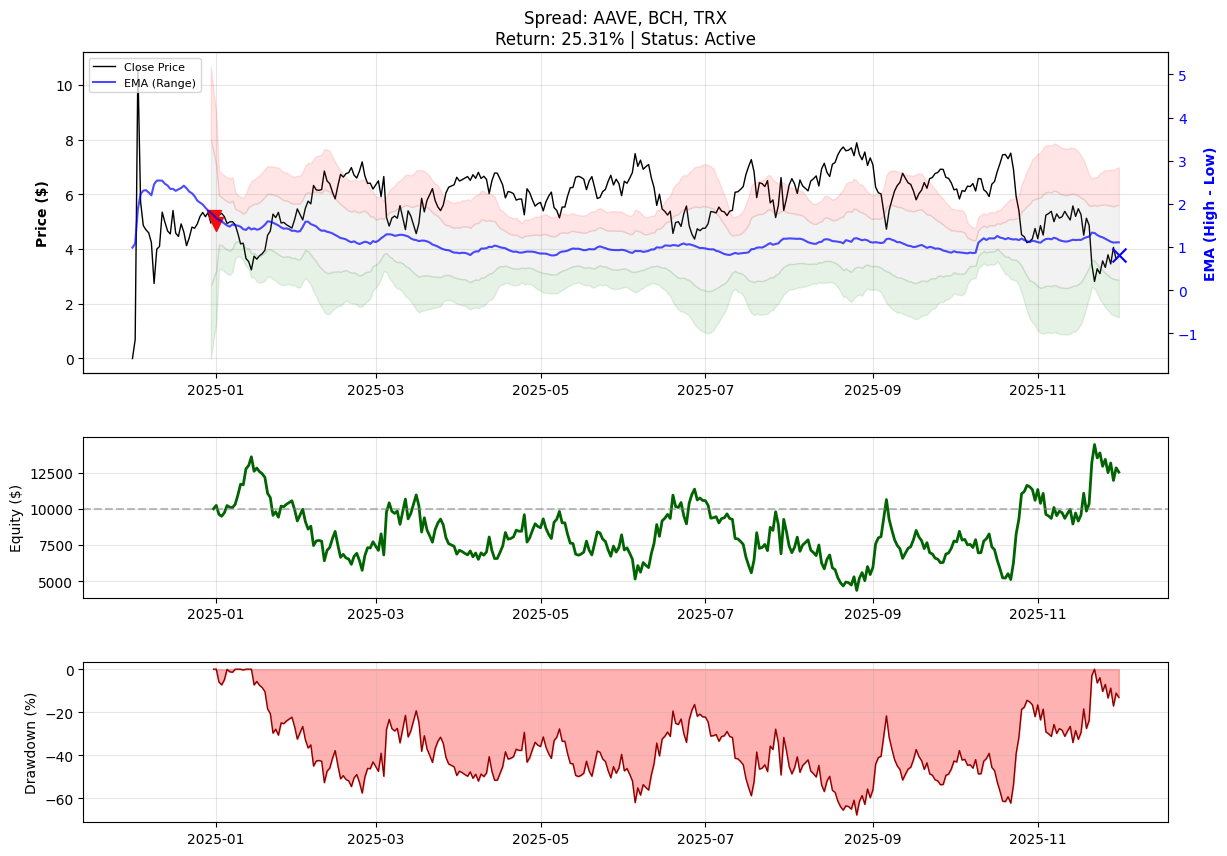


Spread 2: AAVE, ETH, TRX
Half-life: 3.10 days

Performance Metrics:
  Initial Capital: $10000.00
  Final Capital: $9974.42
  Total Return: -0.26%
  Sharpe Ratio: 0.2466
  Max Drawdown: -44.23%
  Number of Trades: 3

Trade Log (first 10 trades):
    1. 2025-01-01: SHORT_1    @ 8.179418
    2. 2025-01-02: SHORT_2    @ 8.584707
    3. 2025-12-01: FINAL_EXIT @ 8.398590


/var/folders/jz/g4w_6r1j2_50nzsyf332vhs80000gn/T/ipykernel_64026/2388229514.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


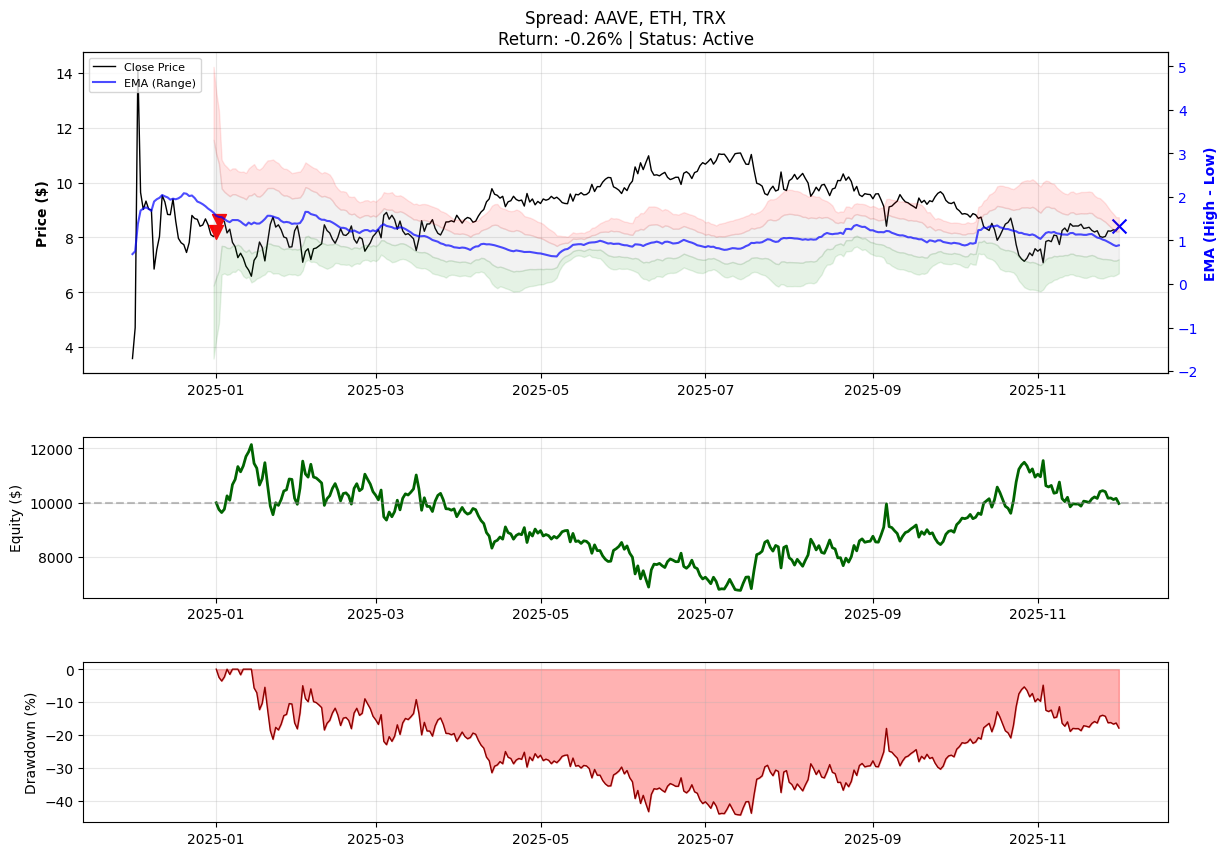


Spread 3: AAVE, BTC, TRX
Half-life: 3.75 days
You are BANKRUPT at 2025-08-28 - Equity hit $-469.42 !!!

Performance Metrics:
  Initial Capital: $10000.00
  Final Capital: $0.00
  Total Return: -100.00%
  Sharpe Ratio: 0.5267
  Max Drawdown: -100.00%
  Number of Trades: 463
  STATUS: BANKRUPT/LIQUIDATED

Trade Log (first 10 trades):
    1. 2025-01-03: LONG_1     @ -0.654760
    2. 2025-01-04: EXIT       @ -0.657501
    3. 2025-01-04: LONG_1     @ -0.657501
    4. 2025-01-05: EXIT       @ -1.072667
    5. 2025-01-05: LONG_1     @ -1.072667
    6. 2025-01-06: EXIT       @ -1.417177
    7. 2025-01-06: LONG_1     @ -1.417177
    8. 2025-01-07: EXIT       @ -1.615115
    9. 2025-01-07: LONG_1     @ -1.615115
    10. 2025-01-08: EXIT       @ -1.545780


/var/folders/jz/g4w_6r1j2_50nzsyf332vhs80000gn/T/ipykernel_64026/2388229514.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


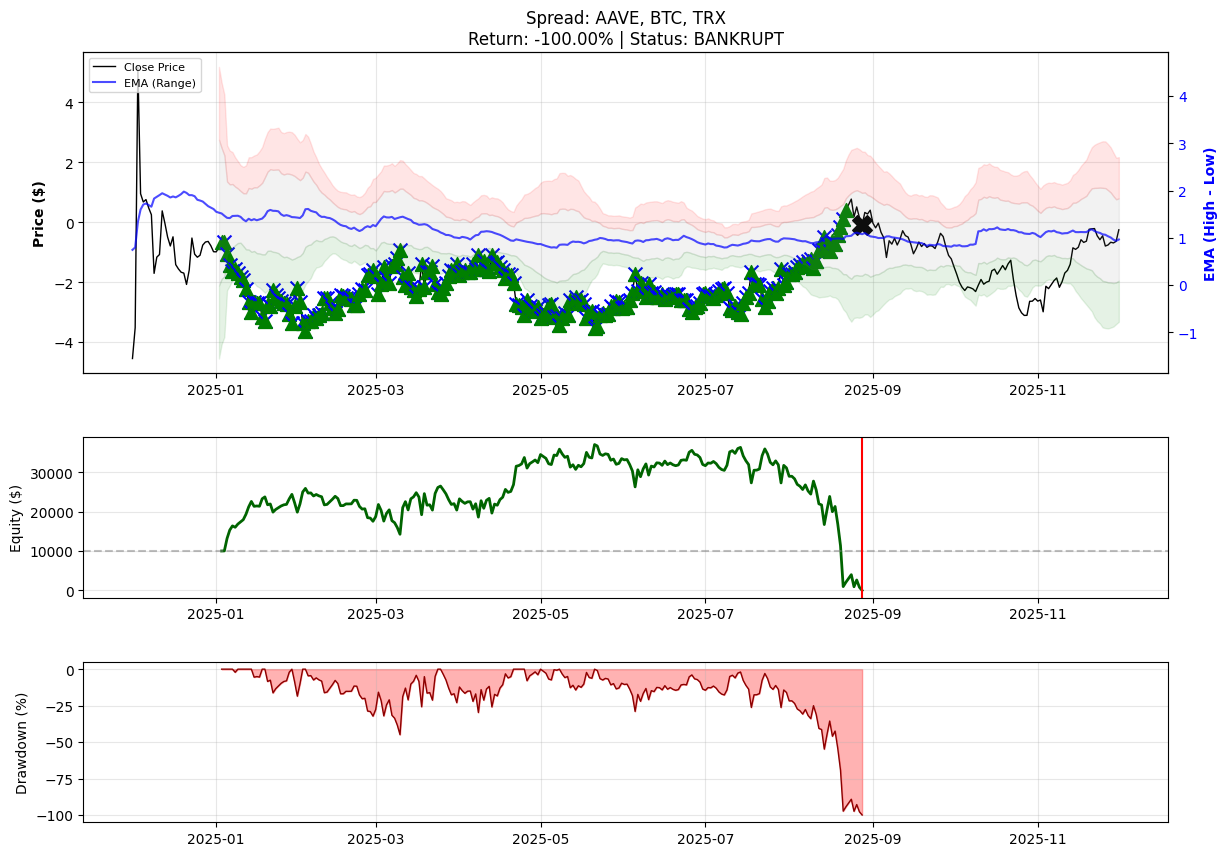


Spread 4: ADA, BCH, HBAR
Half-life: 3.87 days

Performance Metrics:
  Initial Capital: $10000.00
  Final Capital: $531571.96
  Total Return: 5215.72%
  Sharpe Ratio: 1.5620
  Max Drawdown: -74.65%
  Number of Trades: 48

Trade Log (first 10 trades):
    1. 2024-12-31: LONG_1     @ 1.635892
    2. 2025-01-03: EXIT       @ 3.320567
    3. 2025-01-03: LONG_1     @ 3.320567
    4. 2025-01-04: EXIT       @ 3.381104
    5. 2025-01-04: SHORT_1    @ 3.381104
    6. 2025-01-08: EXIT       @ 2.425151
    7. 2025-01-08: SHORT_1    @ 2.425151
    8. 2025-01-09: EXIT       @ 2.470583
    9. 2025-01-11: SHORT_1    @ 2.818478
    10. 2025-01-16: EXIT       @ 1.220973


/var/folders/jz/g4w_6r1j2_50nzsyf332vhs80000gn/T/ipykernel_64026/2388229514.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


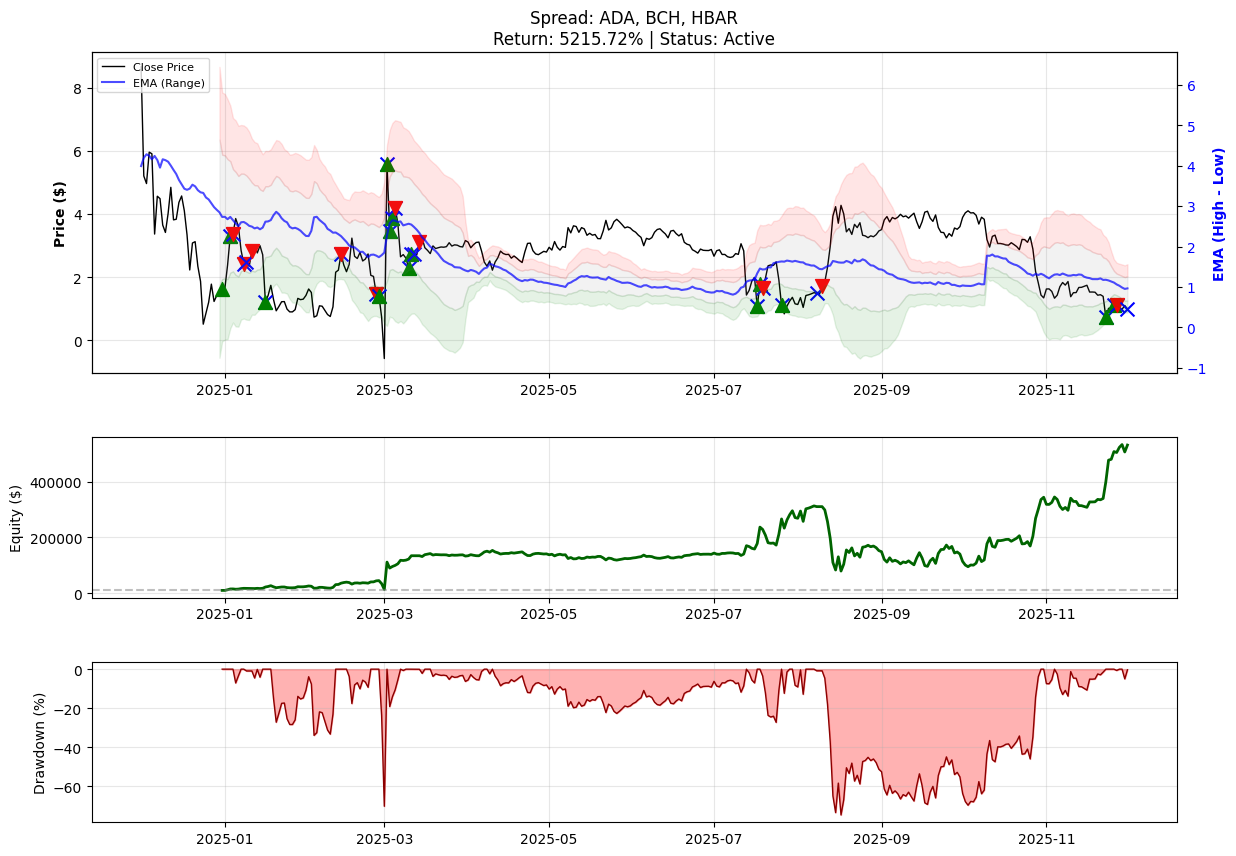


Spread 5: ADA, AVAX, HBAR
Half-life: 4.25 days

Performance Metrics:
  Initial Capital: $10000.00
  Final Capital: $291489.37
  Total Return: 2814.89%
  Sharpe Ratio: 1.5208
  Max Drawdown: -99.60%
  Number of Trades: 29

Trade Log (first 10 trades):
    1. 2025-01-07: LONG_1     @ 2.328084
    2. 2025-01-16: LONG_2     @ 0.574270
    3. 2025-02-17: EXIT       @ 2.581613
    4. 2025-02-17: SHORT_1    @ 2.581613
    5. 2025-02-24: EXIT       @ 1.505361
    6. 2025-02-24: LONG_1     @ 1.505361
    7. 2025-03-02: EXIT       @ 4.491170
    8. 2025-03-02: LONG_1     @ 4.491170
    9. 2025-03-03: EXIT       @ 2.567558
    10. 2025-03-03: LONG_1     @ 2.567558


/var/folders/jz/g4w_6r1j2_50nzsyf332vhs80000gn/T/ipykernel_64026/2388229514.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


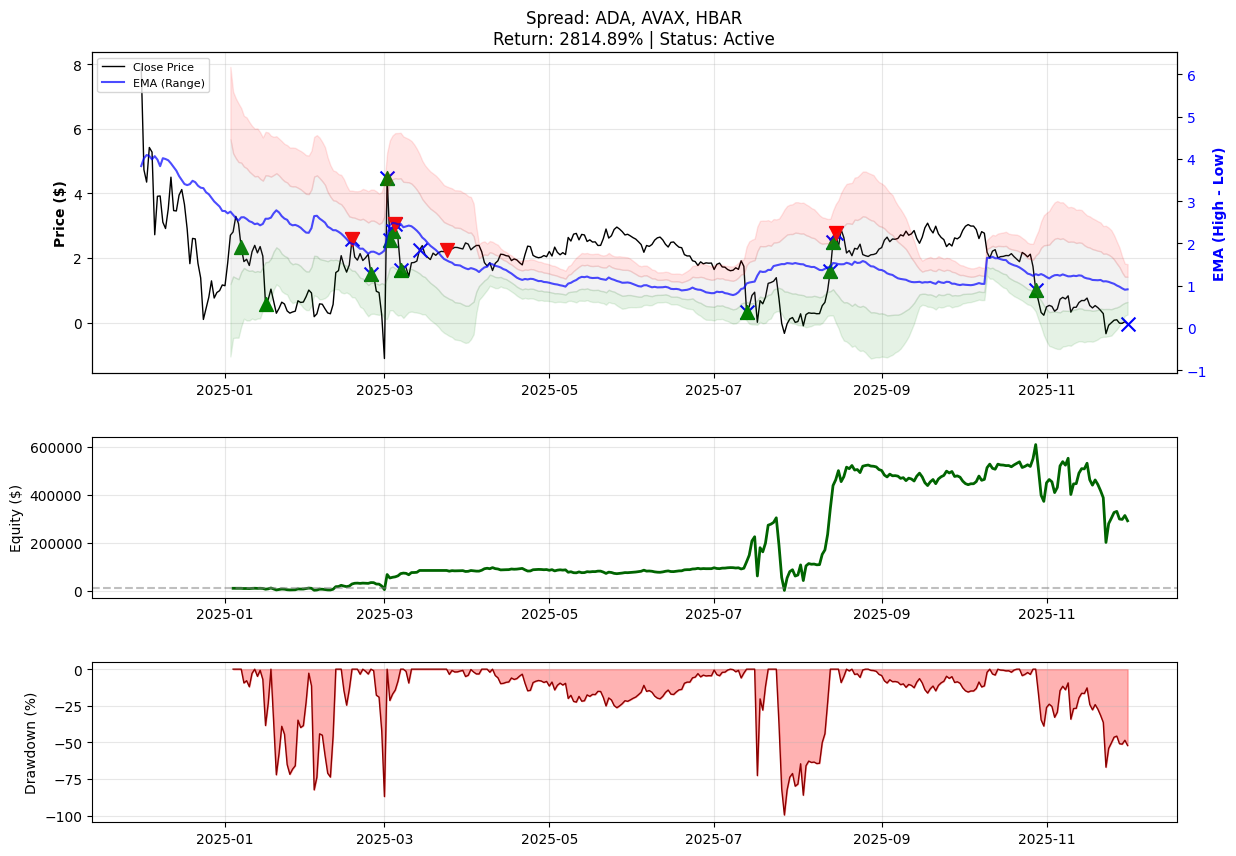

In [208]:
backtest_results = backtest_mean_strategy(topp_five, initial_capital=INITIAL_CAPITAL)

In [209]:
print(f"{'='*100}")
print(f"SUMMARY OF ALL 5 SPREADS")
print(f"{'='*100}")
print(f"{'Spread':<40} {'Return %':>10} {'Sharpe':>10} {'Max DD %':>10} {'Trades':>8}")
print(f"{'-'*100}")
for res in backtest_results:
    spread_name = ', '.join(res['names'][:2]) + ('...' if len(res['names']) > 2 else '')
    print(f"{spread_name:<40} {res['total_return']:>10.2f} {res['sharpe_ratio']:>10.4f} {res['max_drawdown']:>10.2f} {res['num_trades']:>8}")
print(f"{'='*100}")

avg_return = np.mean([r['total_return'] for r in backtest_results])
avg_sharpe = np.mean([r['sharpe_ratio'] for r in backtest_results])
avg_dd = np.mean([r['max_drawdown'] for r in backtest_results])
print(f"{'AVERAGE':<40} {avg_return:>10.2f} {avg_sharpe:>10.4f} {avg_dd:>10.2f}")
print(f"{'='*100}\n")

SUMMARY OF ALL 5 SPREADS
Spread                                     Return %     Sharpe   Max DD %   Trades
----------------------------------------------------------------------------------------------------
AAVE, BCH...                                  25.31     0.9603     -67.79        3
AAVE, ETH...                                  -0.26     0.2466     -44.23        3
AAVE, BTC...                                -100.00     0.5267    -100.00      463
ADA, BCH...                                 5215.72     1.5620     -74.65       48
ADA, AVAX...                                2814.89     1.5208     -99.60       29
AVERAGE                                     1591.13     0.9633     -77.25



## Part 6

In [210]:
def calculate_zero_crossings(series):
    centered = series - series.mean()
    return len(np.where(np.diff(np.sign(centered)))[0])


In [211]:
def select_best_combo_for_window(selection_start, selection_end, data_dir=DATA_SAVE_DIR, alpha=0.05, max_size=5):

    found = find_linear_stationary_combinations(
        data_dir=data_dir, 
        alpha=alpha, 
        target=100, 
        max_size=max_size, 
        start_day=selection_start, 
        end_day=selection_end,
        shuffle=True
    )
    
    if not found:
        return []

    scored_candidates = []

    for f in found:
        spread_series = f.get('spread_ohlc')['Close']
        

        spread_std = spread_series.std()
        if spread_std < 1e-4: 
            continue

        z_crossings = calculate_zero_crossings(spread_series)
        days_in_sample = (pd.to_datetime(selection_end) - pd.to_datetime(selection_start)).days
        
        if z_crossings < (days_in_sample / 60): 
            continue

        adf_p = f.get('adf_p', 1.0)
    
        
        score = 0
        score += z_crossings * 1.5
        
        spread_mean = spread_series.mean()
        if spread_mean != 0:
            cv = abs(spread_std / spread_mean)
            if cv > 3.0: 
                score -= 20
        
        if adf_p < 0.001: 
             pass 
        elif adf_p > 0.05:
            score -= 50
            
        scored_candidates.append((score, f))

    scored_sorted = sorted(scored_candidates, key=lambda x: -x[0])
    
    return [s[1] for s in scored_sorted]


In [212]:
def build_spread_ohlc(names, vec, from_date, to_date, data_dir=DATA_SAVE_DIR):
    files_map = {os.path.basename(p).replace('_1D.csv', ''): p for p in sorted(glob.glob(os.path.join(data_dir, '*_1D.csv')))}
    dfs = []
    for name in names:
        path = files_map.get(name)
        if path is None:
            return None
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        try:
            df = df.loc[from_date:to_date]
        except Exception:
            return None
        if len(df) < 5:
            return None
        dfs.append(df[['Open', 'High', 'Low', 'Close']].copy())

    idx = dfs[0].index
    for d in dfs[1:]:
        idx = idx.intersection(d.index)
    if len(idx) < 5:
        return None

    opens = np.column_stack([d.loc[idx, 'Open'].values for d in dfs])
    highs = np.column_stack([d.loc[idx, 'High'].values for d in dfs])
    lows = np.column_stack([d.loc[idx, 'Low'].values for d in dfs])
    closes = np.column_stack([d.loc[idx, 'Close'].values for d in dfs])

    spread_ohlc = pd.DataFrame(index=idx)
    spread_ohlc['Open'] = opens.dot(vec)
    spread_ohlc['Close'] = closes.dot(vec)

    high_contrib = np.zeros_like(highs[:, 0], dtype=float)
    low_contrib = np.zeros_like(lows[:, 0], dtype=float)
    for j, w in enumerate(vec):
        if w >= 0:
            high_contrib += w * highs[:, j]
            low_contrib += w * lows[:, j]
        else:
            high_contrib += w * lows[:, j]
            low_contrib += w * highs[:, j]

    spread_ohlc['High'] = high_contrib
    spread_ohlc['Low'] = low_contrib
    return spread_ohlc



In [213]:
def backtest_single_spread(item, trade_start, trade_end, initial_capital=INITIAL_CAPITAL, plot=False):    
    names = item['names']
    vec = item['vec']
    hl = item.get('hl', np.nan)

    hist_start = (pd.Timestamp(trade_start) - rd.relativedelta(months=6)).strftime('%Y-%m-%d')
    spread_ohlc = build_spread_ohlc(names, vec, hist_start, trade_end)
    if spread_ohlc is None or len(spread_ohlc) < 10:
        return None

    if np.isnan(hl) or hl <= 0:
        hl = half_life(spread_ohlc['Close'])
        if np.isnan(hl) or hl <= 0:
            hl = 20

    if hl < 30:
        lookback = int(np.ceil(30 / hl) * hl)
    else:
        lookback = int(2 * hl)


    # in class, Dr said that we should use Close instead of High-Low for EMA
    ema = spread_ohlc['Close'].ewm(span=lookback, adjust=False).mean()
    std = spread_ohlc['Close'].rolling(window=lookback).std()
    
    print(f"  Spread {','.join(names)}: Half-life={hl:.2f}, Lookback={lookback}, EMA={ema.iloc[-1]:.4f}, STD={std.iloc[-1]:.4f}")

    capital = initial_capital
    position_value = 0
    entry_price = 0
    position_direction = 0  # +1 for long, -1 for short
    trades = []
    equity_curve = []

    idxs = list(spread_ohlc.index)
    for i, current_date in enumerate(idxs):
        high = spread_ohlc['High'].iloc[i]
        low = spread_ohlc['Low'].iloc[i]
        close = spread_ohlc['Close'].iloc[i]
        current_ema = ema.iloc[i]
        current_std = std.iloc[i]
        if np.isnan(current_ema) or np.isnan(current_std):
            continue

        in_trade_window = (current_date >= pd.Timestamp(trade_start)) and (current_date < pd.Timestamp(trade_end))

        if position_direction != 0 and entry_price != 0:
            spread_change = close - entry_price
            pnl_unrealized = position_value * spread_change / abs(entry_price) * position_direction
            current_value = capital + position_value + pnl_unrealized
        else:
            current_value = capital
        
        if position_direction != 0 and current_value <= 0:
            print(f"  LIQUIDATION on {current_date.date()}: Portfolio value ${current_value:.2f} <= 0")
            trades.append({'date': current_date, 'action': 'LIQUIDATION', 'position': position_direction, 'price': close, 'pnl': -(position_value + capital), 'capital': 0})
            capital = 0.0
            position_value = 0
            entry_price = 0
            position_direction = 0
            if in_trade_window:
                equity_curve.append({'date': current_date, 'equity': 0.0})
            break
        
        if in_trade_window:
            equity_curve.append({'date': current_date, 'equity': current_value})

        if position_direction != 0 and in_trade_window:
            should_exit = (position_direction > 0 and close >= current_ema) or (position_direction < 0 and close <= current_ema)
            if should_exit:
                spread_change = close - entry_price
                pnl = position_value * spread_change / abs(entry_price) * position_direction
                capital += position_value + pnl
                trades.append({'date': current_date, 'action': 'EXIT', 'position': position_direction, 'price': close, 'pnl': pnl, 'capital': capital})
                position = 0
                position_value = 0
                entry_price = 0
                position_direction = 0

        if capital <= 0:
            print(f"Capital depleted (<=0) on {current_date.date()}; stopping trading for this spread.")
            capital = 0.0
            break

        if position_direction == 0 and in_trade_window:
            upper_1std = current_ema + current_std
            lower_1std = current_ema - current_std
            upper_2std = current_ema + 2 * current_std
            lower_2std = current_ema - 2 * current_std

            if low < lower_1std:
                entry_amount = min(capital * 0.5, capital)
                if entry_amount <= 0:
                    continue
                position_direction = 1  # long
                position_value = entry_amount
                entry_price = close
                capital -= entry_amount
                trades.append({'date': current_date, 'action': 'LONG_1', 'position': position_direction, 'price': close, 'amount': entry_amount, 'capital': capital})
            elif high > upper_1std:
                entry_amount = min(capital * 0.5, capital)
                if entry_amount <= 0:
                    continue
                position_direction = -1  # short
                position_value = entry_amount
                entry_price = close
                capital -= entry_amount
                trades.append({'date': current_date, 'action': 'SHORT_1', 'position': position_direction, 'price': close, 'amount': entry_amount, 'capital': capital})


        elif position_direction != 0 and in_trade_window:
            upper_2std = current_ema + 2 * current_std
            lower_2std = current_ema - 2 * current_std
            
            if position_direction > 0 and low < lower_2std:
                entry_amount = capital  
                if entry_amount > 0:
                    new_position_value = position_value + entry_amount
                    avg_price = (position_value * entry_price + entry_amount * close) / new_position_value
                    position_value = new_position_value
                    entry_price = avg_price
                    capital -= entry_amount
                    trades.append({'date': current_date, 'action': 'LONG_2', 'position': position_direction, 'price': close, 'amount': entry_amount, 'capital': capital})
            
            elif position_direction < 0 and high > upper_2std:
                entry_amount = capital  
                if entry_amount > 0:
                    new_position_value = position_value + entry_amount
                    avg_price = (position_value * entry_price + entry_amount * close) / new_position_value
                    position_value = new_position_value
                    entry_price = avg_price
                    capital -= entry_amount
                    trades.append({'date': current_date, 'action': 'SHORT_2', 'position': position_direction, 'price': close, 'amount': entry_amount, 'capital': capital})

        if capital <= 0:
            pass

    last_action = trades[-1]['action'] if trades else None
    position_open_end = last_action not in (None, 'EXIT', 'FINAL_EXIT', 'LIQUIDATION') and ('LONG' in str(last_action) or 'SHORT' in str(last_action))

    equity_df = pd.DataFrame(equity_curve)
    if not equity_df.empty:
        equity_df.set_index('date', inplace=True)
        equity_df['returns'] = equity_df['equity'].pct_change()
        if len(equity_df['returns'].dropna()) > 0:
            mean_return = equity_df['returns'].mean()
            std_return = equity_df['returns'].std()
            daily_rf = RISK_FREE_RATE / 365
            sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(365) if std_return and std_return > 0 else 0.0
        else:
            sharpe = 0.0
        equity_df['cummax'] = equity_df['equity'].cummax()
        equity_df['drawdown'] = (equity_df['equity'] - equity_df['cummax']) / equity_df['cummax']
        max_dd = equity_df['drawdown'].min() * 100 if not equity_df['drawdown'].empty else 0.0
    else:
        sharpe = 0.0
        max_dd = 0.0

    if not equity_df.empty:
        final_capital = float(equity_df['equity'].iloc[-1])
    else:
        final_capital = capital

    total_return = ((final_capital - initial_capital) / initial_capital) * 100.0

    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        ax1.plot(spread_ohlc.index, spread_ohlc['Close'], label='spread', color='black')
        ax1.plot(spread_ohlc.index, ema, label='ema', color='blue')
        ax1.fill_between(spread_ohlc.index, ema - std, ema + std, color='gray', alpha=0.2, label='±1 std')
        for t in trades:
            if 'LONG' in t['action']:
                ax1.scatter(t['date'], t['price'], marker='^', color='green')
            elif 'SHORT' in t['action']:
                ax1.scatter(t['date'], t['price'], marker='v', color='red')
            elif t['action'] == 'EXIT':
                ax1.scatter(t['date'], t['price'], marker='x', color='blue')
        ax1.set_title(f"Spread {','.join(names)} | Return {total_return:.2f}% | Sharpe {sharpe:.2f} | MaxDD {max_dd:.2f}%")
        ax1.legend()

        if not equity_df.empty:
            ax2.plot(equity_df.index, equity_df['equity'], color='darkgreen')
            ax2.set_title('Equity Curve')
            ax2.axhline(initial_capital, color='gray', linestyle='--')

        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()


    return {
        'trades': trades,
        'final_capital': final_capital,
        'position_open_end': position_open_end,
        'spread_ohlc': spread_ohlc,
        'lookback': lookback,
        'equity_df': equity_df,
        'total_return': total_return,
        'sharpe': sharpe,
        'max_drawdown': max_dd
    }


In [214]:
def handle_extended_position(chosen, trade_start, trade_end, month_start_capital, res):
    print("position remained open at month end. Waiting until it closes before reselection")
    
    search_start = trade_end
    search_limit = trade_end + rd.relativedelta(months=6)
    closed = False
    
    final_capital = float(res.get('final_capital', month_start_capital))
    next_date = trade_end

    while search_start < search_limit:
        res_future = backtest_single_spread(
            chosen, 
            trade_start.strftime('%Y-%m-%d'), 
            (search_start + rd.relativedelta(days=1)).strftime('%Y-%m-%d'), 
            initial_capital=month_start_capital
        )
        
        if res_future is None:
            search_start += rd.relativedelta(days=1)
            continue
            
        if not res_future['position_open_end']:
            closed = True
            close_date = None
            
            if res_future['trades']:
                for t in reversed(res_future['trades']):
                    if t['action'] == 'EXIT':
                        close_date = t['date']
                        break
            
            if close_date is None:
                close_date = (search_start + rd.relativedelta(days=1))
                
            print(f'Position closed on {close_date.date()}. Next selection will be relative to that date.')

            final_capital = float(res_future.get('final_capital', month_start_capital))
            next_date = pd.Timestamp(close_date) + rd.relativedelta(days=1)
            break
            
        search_start += rd.relativedelta(days=1)

    if not closed:
        print("position did not close within search limit. going to next month.")
        final_capital = float(res.get('final_capital', month_start_capital))
        next_date = trade_end

    return final_capital, next_date


In [215]:
def print_metrics(results):
    all_equity_points = []
    for r in results:
        eq_df = r['backtest'].get('equity_df')
        if eq_df is not None and not eq_df.empty:
            for date, row in eq_df.iterrows():
                all_equity_points.append({'date': date, 'equity': row['equity']})
    
    if all_equity_points:
        equity_full = pd.DataFrame(all_equity_points)
        equity_full = equity_full.sort_values('date').drop_duplicates(subset='date', keep='last')
        equity_full.set_index('date', inplace=True)
        
        equity_full['returns'] = equity_full['equity'].pct_change()
        daily_returns = equity_full['returns'].dropna()
        
        if len(daily_returns) > 1:
            mean_ret = daily_returns.mean()
            std_ret = daily_returns.std()
            daily_rf = RISK_FREE_RATE / 365
            overall_sharpe = ((mean_ret - daily_rf) / std_ret) * np.sqrt(365) if std_ret > 0 else 0
            print(f"Overall Sharpe Ratio: {overall_sharpe:.4f}")
            
            equity_full['cummax'] = equity_full['equity'].cummax()
            equity_full['drawdown'] = (equity_full['equity'] - equity_full['cummax']) / equity_full['cummax']
            overall_max_dd = equity_full['drawdown'].min() * 100
            print(f"Overall Max Drawdown: {overall_max_dd:.2f}%")


def print_period_breakdown(results):
    print(f"PERIOD-BY-PERIOD BREAKDOWN")
    print(f"{'='*80}")
    print(f"{'Period':<23} {'Combination':<40} {'Trades':>7} {'Return %':>10} {'Final Cap':>12}")
    print(f"{'-'*80}")
    
    for i, r in enumerate(results, 1):
        period_str = f"{r['period_start'].strftime('%Y-%m-%d')} to {r['period_end'].strftime('%Y-%m-%d')}"
        combo_str = ', '.join(r['chosen']['names'][:3])
        if len(r['chosen']['names']) > 3:
            combo_str += '...'
        num_trades = len(r['backtest']['trades'])
        period_return = r['backtest']['total_return']
        final_cap = r['backtest']['final_capital']
        
        print(f"{period_str:<23} {combo_str:<40} {num_trades:>7} {period_return:>10.2f} ${final_cap:>11.2f}")
    
    print(f"{'='*80}")


def print_unique_combinations(results):

    unique_combos = {}
    for r in results:
        combo_tuple = tuple(sorted(r['chosen']['names']))
        if combo_tuple not in unique_combos:
            unique_combos[combo_tuple] = {
                'count': 0,
                'periods': [],
                'vec': r['chosen']['vec'],
                'hl': r['chosen'].get('hl', np.nan),
                'hurst': r['chosen'].get('hurst', np.nan),
                'equity_points': []
            }
        unique_combos[combo_tuple]['count'] += 1
        unique_combos[combo_tuple]['periods'].append(r['period_start'].strftime('%Y-%m'))
        
        eq_df = r['backtest'].get('equity_df')
        if eq_df is not None and not eq_df.empty:
            for date, row in eq_df.iterrows():
                unique_combos[combo_tuple]['equity_points'].append({'date': date, 'equity': row['equity']})
    
    for combo_tuple, info in unique_combos.items():
        if info['equity_points']:
            combo_equity = pd.DataFrame(info['equity_points'])
            combo_equity = combo_equity.sort_values('date').drop_duplicates(subset='date', keep='last')
            combo_equity.set_index('date', inplace=True)
            combo_equity['returns'] = combo_equity['equity'].pct_change()
            daily_returns = combo_equity['returns'].dropna()
            
            if len(daily_returns) > 1:
                mean_ret = daily_returns.mean()
                std_ret = daily_returns.std()
                daily_rf = 0.03 / 365
                combo_sharpe = ((mean_ret - daily_rf) / std_ret) * np.sqrt(365) if std_ret > 0 else 0
                info['sharpe'] = combo_sharpe
            else:
                info['sharpe'] = 0.0
        else:
            info['sharpe'] = 0.0
    
    for i, (combo, info) in enumerate(sorted(unique_combos.items(), key=lambda x: -x[1]['count']), 1):
        print(f"\n{i}. {', '.join(combo)}")
        print(f"   Selected {info['count']} time(s): {', '.join(info['periods'])}")
        print(f"   Weights: {', '.join([f'{w:.4f}' for w in info['vec']])}")
        print(f"   Half-life: {info['hl']:.2f}, Hurst: {info['hurst']:.4f}")
        print(f"   Sharpe Ratio: {info['sharpe']:.4f}")

In [216]:
def get_report(results, start_str, end_str, initial_capital, final_capital):
    print(f"Period: {start_str} to {end_str}")
    print(f"Initial Capital: ${initial_capital:.2f}")
    print(f"Final Capital: ${final_capital:.2f}")
    
    total_return_pct = ((final_capital - initial_capital) / initial_capital) * 100
    print(f"Total Return: {total_return_pct:.2f}%")
    print(f"Number of Selection Periods: {len(results)}")
    
    if results:
        all_trades = sum(len(r['backtest']['trades']) for r in results)
        print(f"Total Trades: {all_trades}")
        
        print_metrics(results)
    
    print(f"{'='*80}")
    print_period_breakdown(results)
    print_unique_combinations(results)
    print(f"\n{'='*80}\n")

In [217]:
def run_new_strategy(start='2025-01-01', end='2025-12-01', data_dir=DATA_SAVE_DIR, initial_capital=INITIAL_CAPITAL, plot=False):
    cur = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    current_capital = float(initial_capital)
    results = []

    while cur < end_ts:
        trade_start = cur
        trade_end = (cur + rd.relativedelta(months=1))
        sel_start = (trade_start - rd.relativedelta(months=6)).strftime('%Y-%m-%d')
        sel_end = (trade_start - rd.relativedelta(days=1)).strftime('%Y-%m-%d')

        print(f"===== Month {trade_start.strftime('%Y-%m-%d')} to {trade_end.strftime('%Y-%m-%d')} | Selection window {sel_start} to {sel_end} =====")

        candidates = select_best_combo_for_window(sel_start, sel_end, data_dir=data_dir)
        if not candidates:
            print('No candidates found for selection window.')
            cur = trade_end
            continue

        chosen = candidates[0]
        print('Chosen combo:', chosen['names'])

        if current_capital <= 0:
            print(f"Capital depleted to ${current_capital:.2f}. Stopping walk-forward backtest.")
            break
        
        month_start_capital = current_capital

        res = backtest_single_spread(
            chosen, 
            trade_start.strftime('%Y-%m-%d'), 
            trade_end.strftime('%Y-%m-%d'), 
            initial_capital=month_start_capital, 
            plot=plot
        )
        
        if res is None:
            print('Backtest failed or insufficient data for chosen combo.')
            cur = trade_end
            continue

        results.append({'period_start': trade_start, 'period_end': trade_end, 'chosen': chosen, 'backtest': res})

        if res['position_open_end']:
            current_capital, next_start_date = handle_extended_position(
                chosen, trade_start, trade_end, month_start_capital, res
            )
            cur = next_start_date
        else:
            current_capital = float(res.get('final_capital', month_start_capital))
            cur = trade_end

    
    return results


===== Month 2025-01-01 to 2025-02-01 | Selection window 2024-07-01 to 2024-12-31 =====

Stable coins (p-value) in the period from 2024-07-01 to 2024-12-31:
PYUSD: 0.000078
USDC: 0.000112
HBAR: 0.000114
XMR: 0.002091
LEO: 0.004674
BNB: 0.017942
  Combo ('ENA', 'BGB', 'BTC'): trace0=26.76, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
  Combo ('ENA', 'BGB', 'ICP'): trace0=28.88, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
  Combo ('ENA', 'BGB', 'SUI'): trace0=30.29, cv95[0,1]=29.80, cv95[0,2]=nan, pass=True
ADF Statistic: -3.910478
p-value: 0.001959
Half-life: 0.47
  Combo ('ENA', 'BGB', 'M'): trace0=28.61, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
  Combo ('ENA', 'BGB', 'ADA'): trace0=28.05, cv95[0,1]=29.80, cv95[0,2]=nan, pass=False
ADF Statistic: -6.022488
p-value: 0.000000
Half-life: 0.39
ADF Statistic: -1.658413
p-value: 0.452656
Half-life: 0.54
ADF Statistic: -3.220945
p-value: 0.018804
Half-life: 0.90
ADF Statistic: -2.352527
p-value: 0.155586
Half-life: 1.13
ADF Statistic: -2.632887

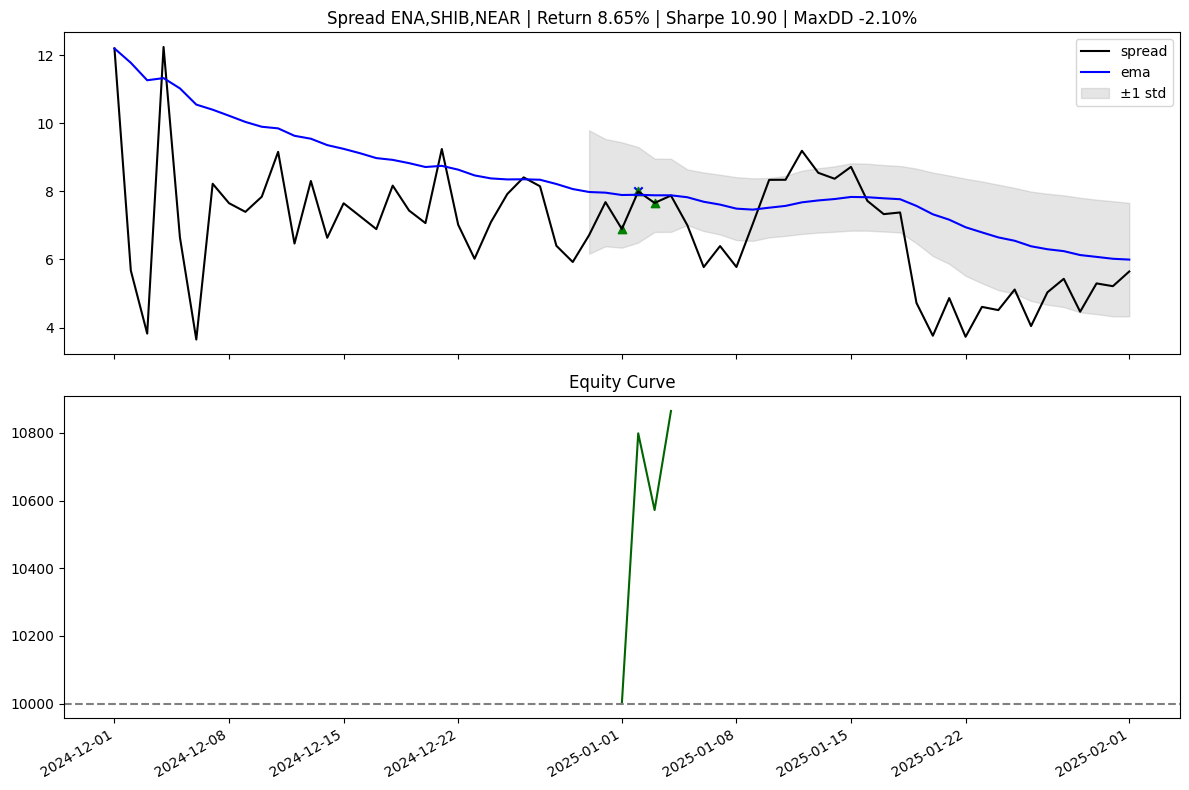

position remained open at month end. Waiting until it closes before reselection
Half-life: 0.64
  Spread ENA,SHIB,NEAR: Half-life=0.64, Lookback=30, EMA=5.8120, STD=1.7376
Capital depleted (<=0) on 2025-01-04; stopping trading for this spread.
Half-life: 0.58
  Spread ENA,SHIB,NEAR: Half-life=0.58, Lookback=30, EMA=5.9295, STD=1.7297
Capital depleted (<=0) on 2025-01-04; stopping trading for this spread.
Half-life: 0.59
  Spread ENA,SHIB,NEAR: Half-life=0.59, Lookback=30, EMA=6.0860, STD=1.7709
Capital depleted (<=0) on 2025-01-04; stopping trading for this spread.
Half-life: 0.61
  Spread ENA,SHIB,NEAR: Half-life=0.61, Lookback=30, EMA=6.2860, STD=1.8536
Capital depleted (<=0) on 2025-01-04; stopping trading for this spread.
Half-life: 0.61
  Spread ENA,SHIB,NEAR: Half-life=0.61, Lookback=30, EMA=6.3870, STD=1.8761
Capital depleted (<=0) on 2025-01-04; stopping trading for this spread.
Half-life: 0.62
  Spread ENA,SHIB,NEAR: Half-life=0.62, Lookback=30, EMA=6.4560, STD=1.8846
Capital 

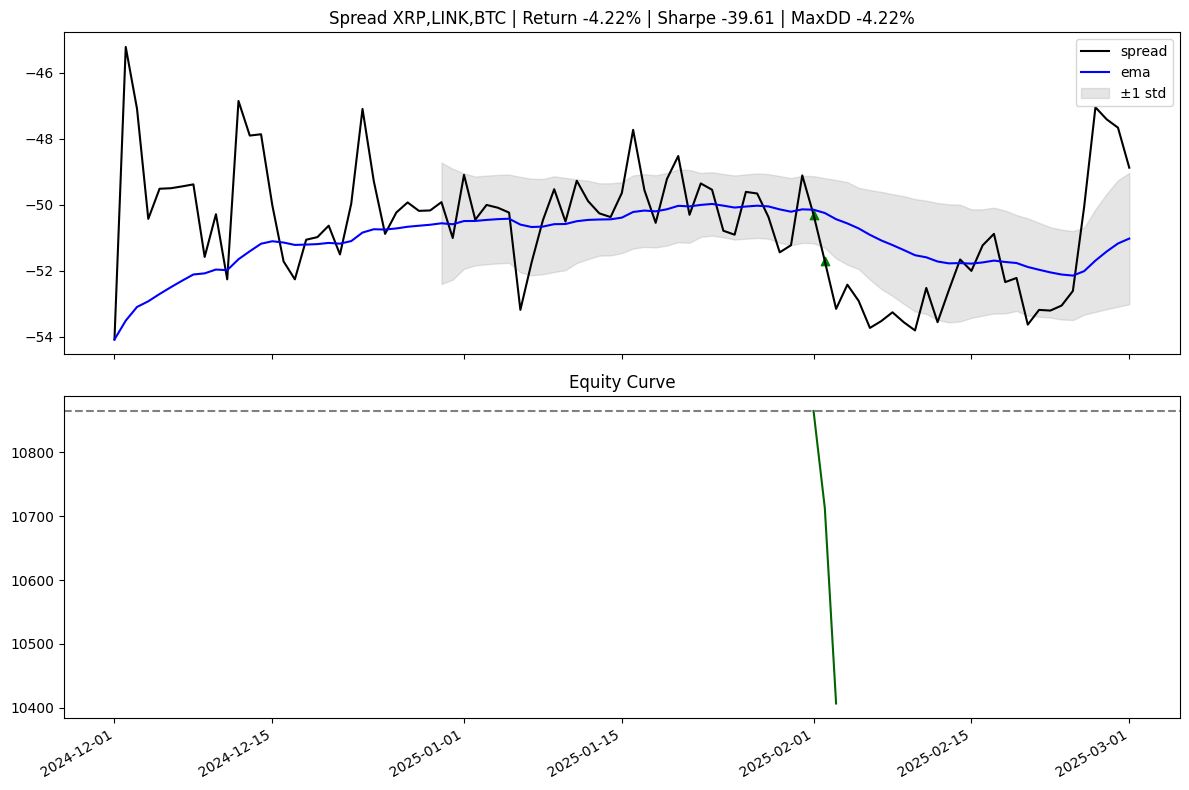

position remained open at month end. Waiting until it closes before reselection
  Spread XRP,LINK,BTC: Half-life=0.34, Lookback=30, EMA=-50.9415, STD=1.9682
Capital depleted (<=0) on 2025-02-03; stopping trading for this spread.
  Spread XRP,LINK,BTC: Half-life=0.34, Lookback=30, EMA=-50.7657, STD=2.0576
Capital depleted (<=0) on 2025-02-03; stopping trading for this spread.
  Spread XRP,LINK,BTC: Half-life=0.34, Lookback=30, EMA=-50.6172, STD=2.1422
Capital depleted (<=0) on 2025-02-03; stopping trading for this spread.
  Spread XRP,LINK,BTC: Half-life=0.34, Lookback=30, EMA=-50.5576, STD=2.1498
Capital depleted (<=0) on 2025-02-03; stopping trading for this spread.
  Spread XRP,LINK,BTC: Half-life=0.34, Lookback=30, EMA=-50.3961, STD=2.2317
Capital depleted (<=0) on 2025-02-03; stopping trading for this spread.
  Spread XRP,LINK,BTC: Half-life=0.34, Lookback=30, EMA=-50.2067, STD=2.3209
Capital depleted (<=0) on 2025-02-03; stopping trading for this spread.
  Spread XRP,LINK,BTC: Hal

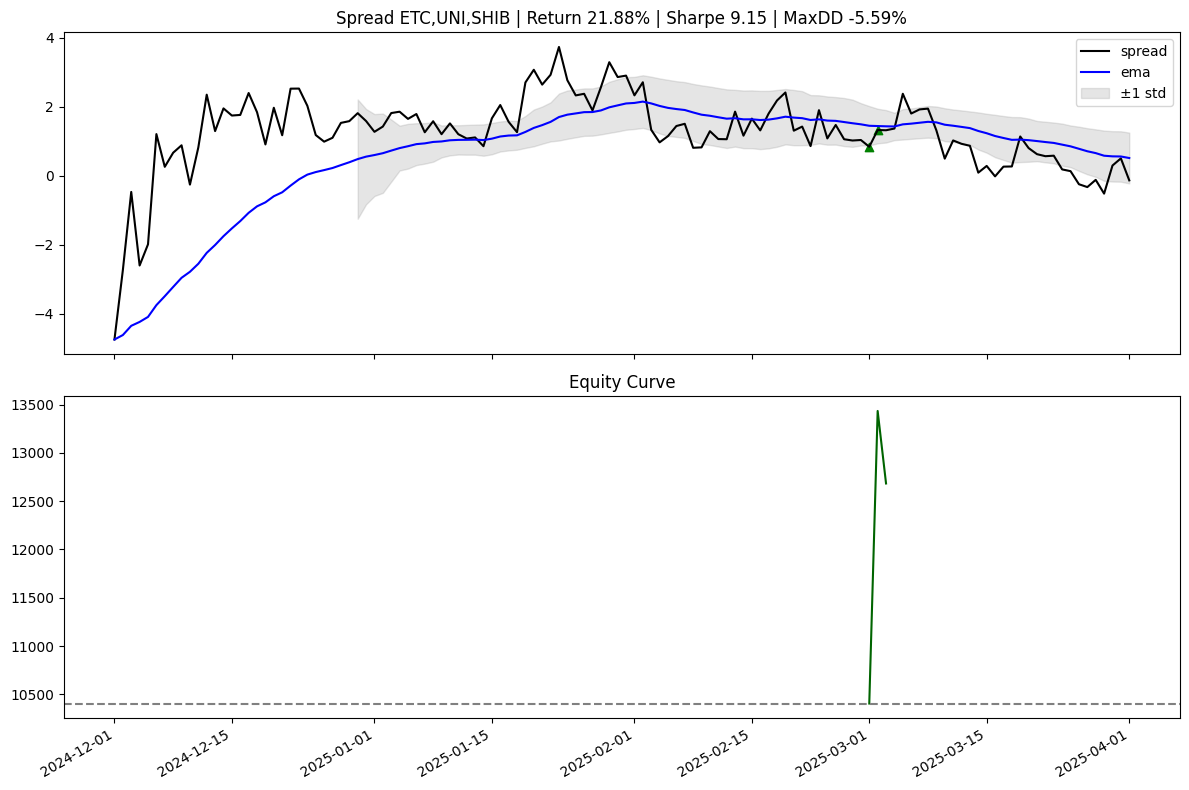

position remained open at month end. Waiting until it closes before reselection
  Spread ETC,UNI,SHIB: Half-life=1.62, Lookback=30, EMA=0.4854, STD=0.7317
Capital depleted (<=0) on 2025-03-03; stopping trading for this spread.
  Spread ETC,UNI,SHIB: Half-life=1.62, Lookback=30, EMA=0.4663, STD=0.7216
Capital depleted (<=0) on 2025-03-03; stopping trading for this spread.
  Spread ETC,UNI,SHIB: Half-life=1.62, Lookback=30, EMA=0.4509, STD=0.6389
Capital depleted (<=0) on 2025-03-03; stopping trading for this spread.
  Spread ETC,UNI,SHIB: Half-life=1.62, Lookback=30, EMA=0.4252, STD=0.5948
Capital depleted (<=0) on 2025-03-03; stopping trading for this spread.
  Spread ETC,UNI,SHIB: Half-life=1.62, Lookback=30, EMA=0.3747, STD=0.5433
Capital depleted (<=0) on 2025-03-03; stopping trading for this spread.
  Spread ETC,UNI,SHIB: Half-life=1.62, Lookback=30, EMA=0.3382, STD=0.4642
Capital depleted (<=0) on 2025-03-03; stopping trading for this spread.
  Spread ETC,UNI,SHIB: Half-life=1.62,

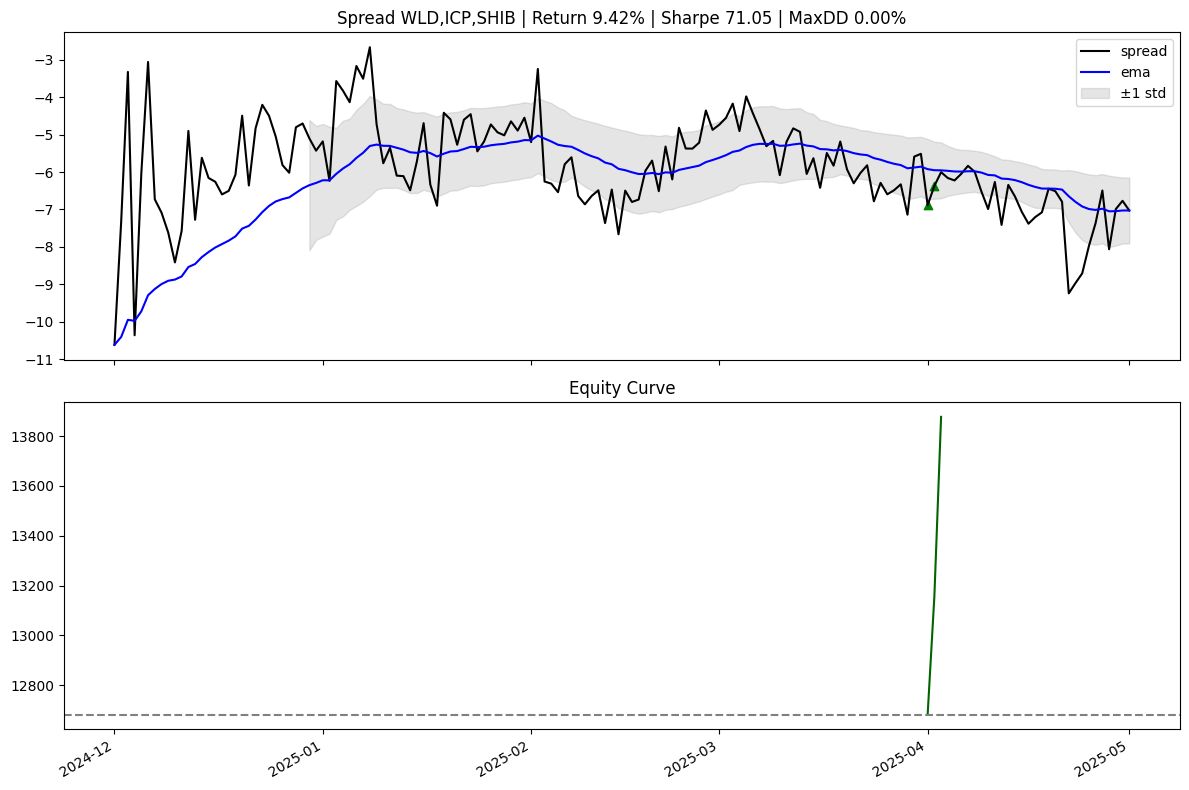

position remained open at month end. Waiting until it closes before reselection
  Spread WLD,ICP,SHIB: Half-life=0.67, Lookback=30, EMA=-7.0248, STD=0.8746
Capital depleted (<=0) on 2025-04-03; stopping trading for this spread.
  Spread WLD,ICP,SHIB: Half-life=0.67, Lookback=30, EMA=-7.0816, STD=0.8700
Capital depleted (<=0) on 2025-04-03; stopping trading for this spread.
  Spread WLD,ICP,SHIB: Half-life=0.67, Lookback=30, EMA=-7.1613, STD=0.8832
Capital depleted (<=0) on 2025-04-03; stopping trading for this spread.
  Spread WLD,ICP,SHIB: Half-life=0.67, Lookback=30, EMA=-7.2490, STD=0.9023
Capital depleted (<=0) on 2025-04-03; stopping trading for this spread.
  Spread WLD,ICP,SHIB: Half-life=0.67, Lookback=30, EMA=-7.3130, STD=0.8949
Capital depleted (<=0) on 2025-04-03; stopping trading for this spread.
  Spread WLD,ICP,SHIB: Half-life=0.67, Lookback=30, EMA=-7.3697, STD=0.8678
Capital depleted (<=0) on 2025-04-03; stopping trading for this spread.
  Spread WLD,ICP,SHIB: Half-life

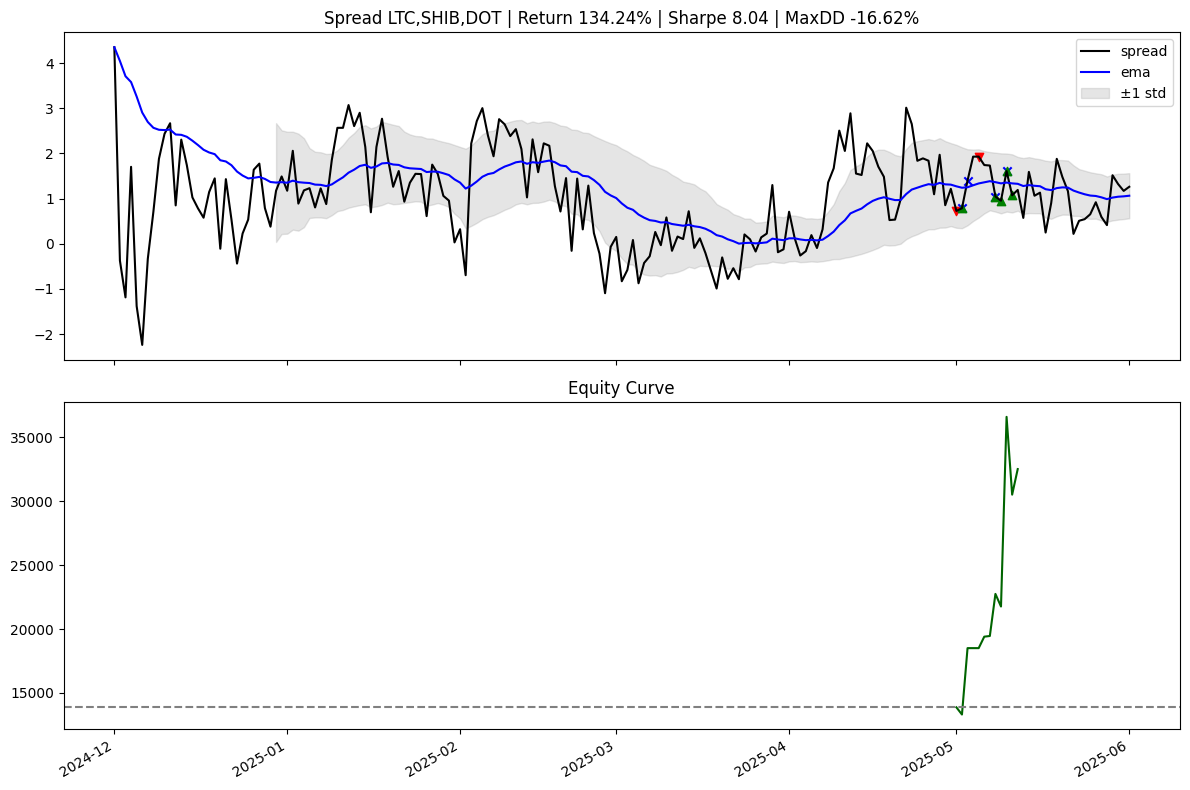

position remained open at month end. Waiting until it closes before reselection
  Spread LTC,SHIB,DOT: Half-life=1.47, Lookback=30, EMA=1.0527, STD=0.4990
Capital depleted (<=0) on 2025-05-12; stopping trading for this spread.
  Spread LTC,SHIB,DOT: Half-life=1.47, Lookback=30, EMA=1.0429, STD=0.4755
Capital depleted (<=0) on 2025-05-12; stopping trading for this spread.
  Spread LTC,SHIB,DOT: Half-life=1.47, Lookback=30, EMA=1.0714, STD=0.4542
Capital depleted (<=0) on 2025-05-12; stopping trading for this spread.
  Spread LTC,SHIB,DOT: Half-life=1.47, Lookback=30, EMA=1.0552, STD=0.4373
Capital depleted (<=0) on 2025-05-12; stopping trading for this spread.
  Spread LTC,SHIB,DOT: Half-life=1.47, Lookback=30, EMA=1.0214, STD=0.4255
Capital depleted (<=0) on 2025-05-12; stopping trading for this spread.
  Spread LTC,SHIB,DOT: Half-life=1.47, Lookback=30, EMA=1.0480, STD=0.4331
Capital depleted (<=0) on 2025-05-12; stopping trading for this spread.
  Spread LTC,SHIB,DOT: Half-life=1.47,

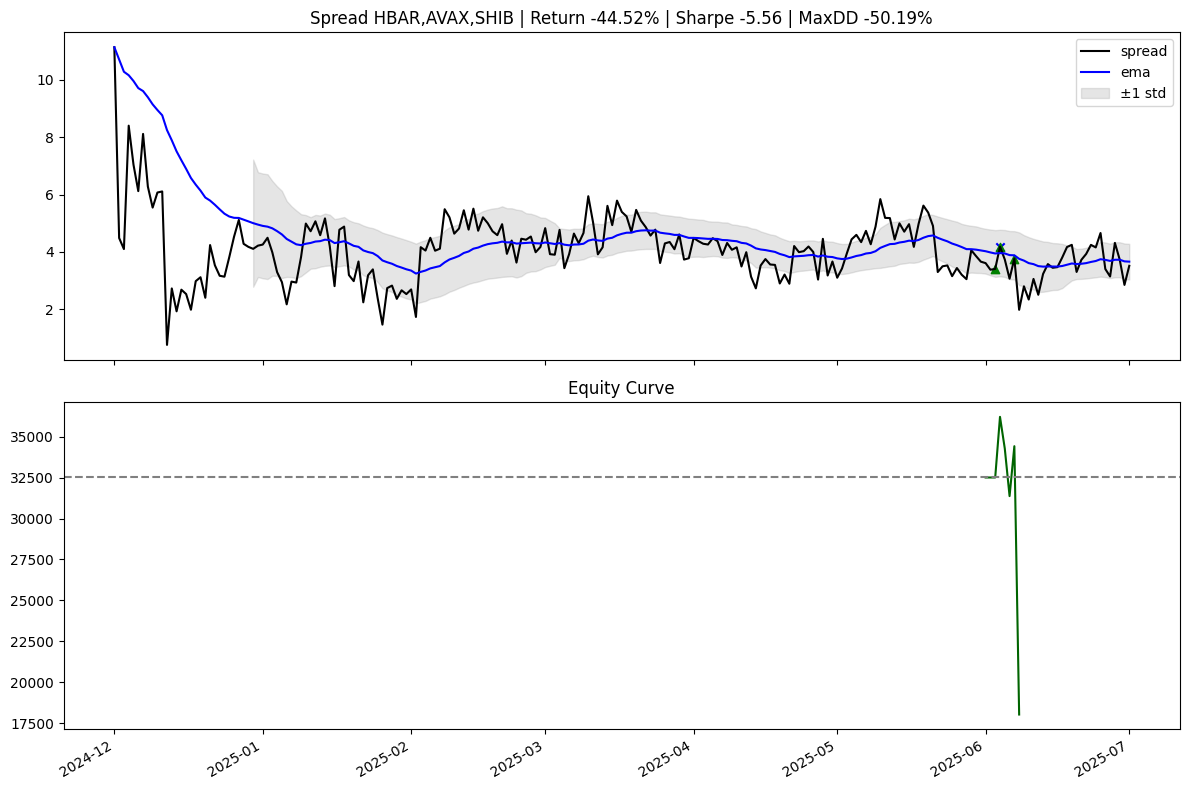

position remained open at month end. Waiting until it closes before reselection
  Spread HBAR,AVAX,SHIB: Half-life=1.14, Lookback=30, EMA=3.6783, STD=0.6262
Capital depleted (<=0) on 2025-06-08; stopping trading for this spread.
  Spread HBAR,AVAX,SHIB: Half-life=1.14, Lookback=30, EMA=3.6950, STD=0.6303
Capital depleted (<=0) on 2025-06-08; stopping trading for this spread.
  Spread HBAR,AVAX,SHIB: Half-life=1.14, Lookback=30, EMA=3.6510, STD=0.6254
Capital depleted (<=0) on 2025-06-08; stopping trading for this spread.
  Spread HBAR,AVAX,SHIB: Half-life=1.14, Lookback=30, EMA=3.6034, STD=0.6328
Capital depleted (<=0) on 2025-06-08; stopping trading for this spread.
  Spread HBAR,AVAX,SHIB: Half-life=1.14, Lookback=30, EMA=3.6377, STD=0.6390
Capital depleted (<=0) on 2025-06-08; stopping trading for this spread.
  Spread HBAR,AVAX,SHIB: Half-life=1.14, Lookback=30, EMA=3.6845, STD=0.6563
Capital depleted (<=0) on 2025-06-08; stopping trading for this spread.
  Spread HBAR,AVAX,SHIB: H

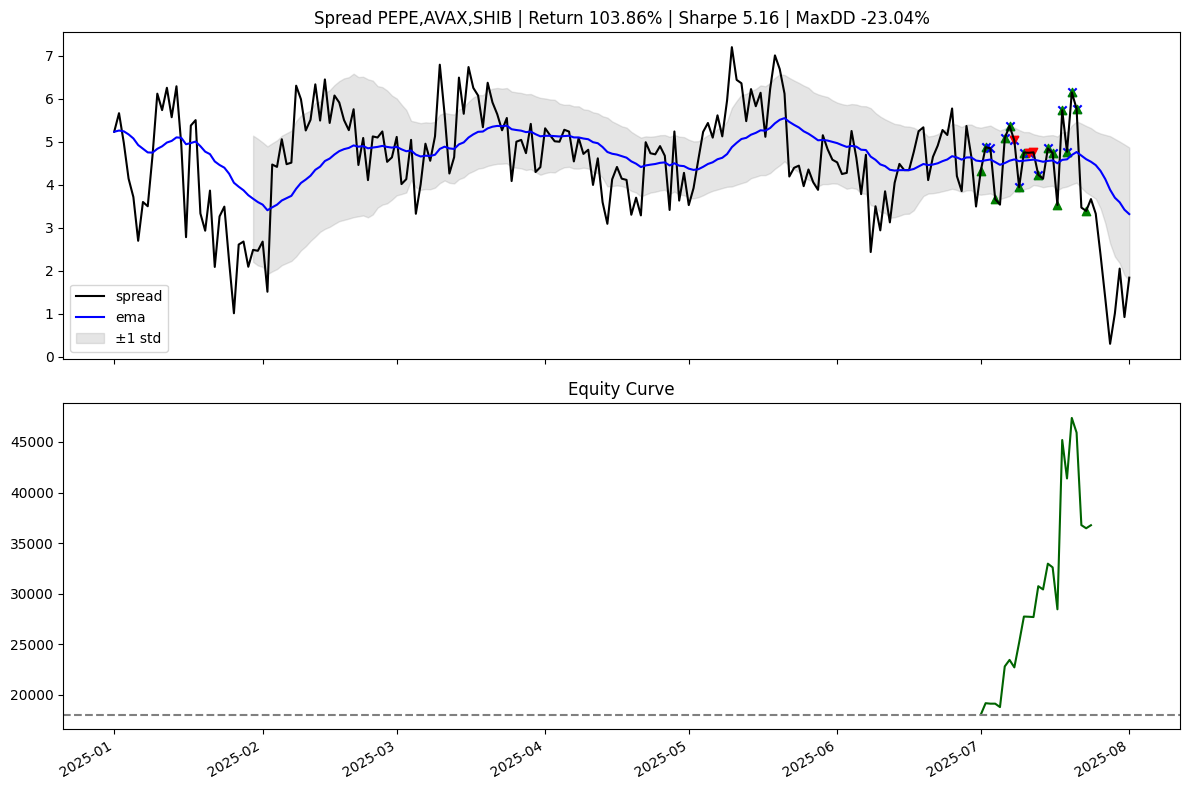

position remained open at month end. Waiting until it closes before reselection
  Spread PEPE,AVAX,SHIB: Half-life=1.81, Lookback=30, EMA=3.2691, STD=1.5536
Capital depleted (<=0) on 2025-07-24; stopping trading for this spread.
  Spread PEPE,AVAX,SHIB: Half-life=1.81, Lookback=30, EMA=3.1890, STD=1.5835
Capital depleted (<=0) on 2025-07-24; stopping trading for this spread.
  Spread PEPE,AVAX,SHIB: Half-life=1.81, Lookback=30, EMA=3.1268, STD=1.6047
Capital depleted (<=0) on 2025-07-24; stopping trading for this spread.
  Spread PEPE,AVAX,SHIB: Half-life=1.81, Lookback=30, EMA=3.0207, STD=1.6247
Capital depleted (<=0) on 2025-07-24; stopping trading for this spread.
  Spread PEPE,AVAX,SHIB: Half-life=1.81, Lookback=30, EMA=2.9020, STD=1.6369
Capital depleted (<=0) on 2025-07-24; stopping trading for this spread.
  Spread PEPE,AVAX,SHIB: Half-life=1.81, Lookback=30, EMA=2.8434, STD=1.6227
Capital depleted (<=0) on 2025-07-24; stopping trading for this spread.
  Spread PEPE,AVAX,SHIB: H

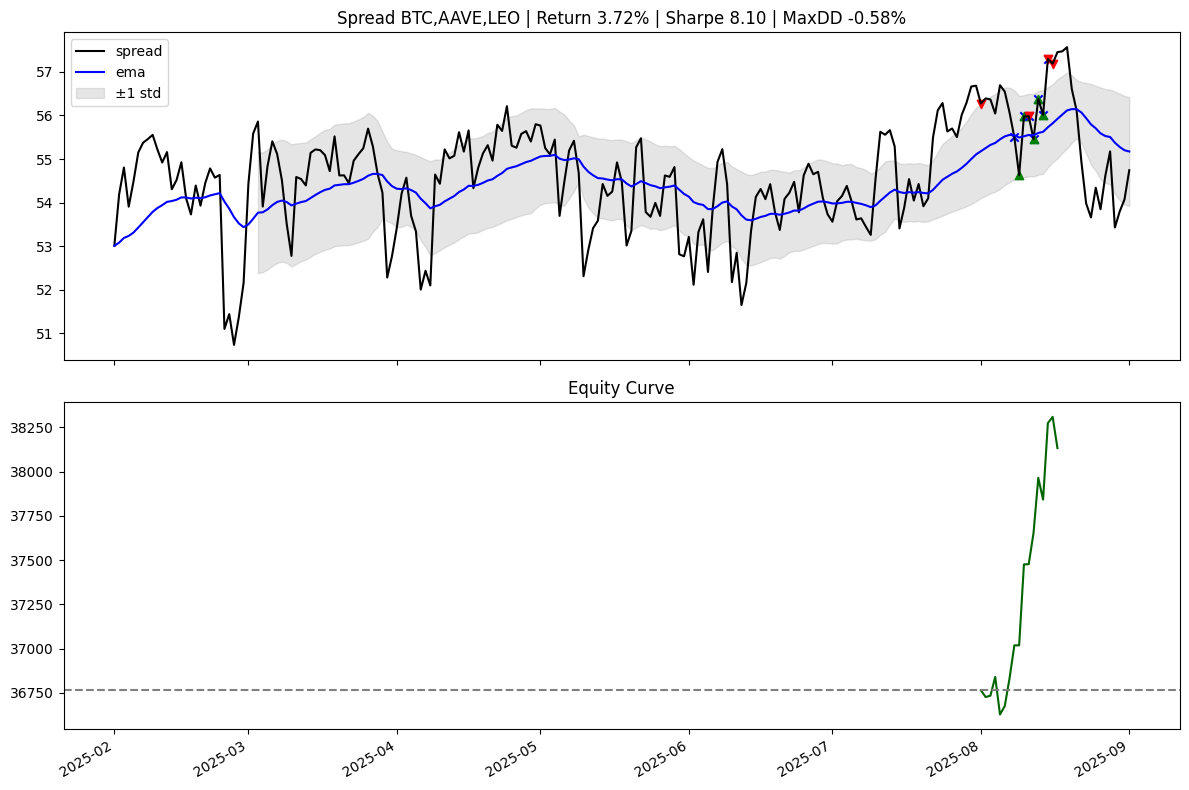

position remained open at month end. Waiting until it closes before reselection
  Spread BTC,AAVE,LEO: Half-life=2.21, Lookback=31, EMA=55.1511, STD=1.2485
Capital depleted (<=0) on 2025-08-17; stopping trading for this spread.
  Spread BTC,AAVE,LEO: Half-life=2.21, Lookback=31, EMA=55.0843, STD=1.2673
Capital depleted (<=0) on 2025-08-17; stopping trading for this spread.
  Spread BTC,AAVE,LEO: Half-life=2.21, Lookback=31, EMA=55.0805, STD=1.2660
Capital depleted (<=0) on 2025-08-17; stopping trading for this spread.
  Spread BTC,AAVE,LEO: Half-life=2.21, Lookback=31, EMA=55.0900, STD=1.2458
Capital depleted (<=0) on 2025-08-17; stopping trading for this spread.
  Spread BTC,AAVE,LEO: Half-life=2.21, Lookback=31, EMA=55.1147, STD=1.2283
Capital depleted (<=0) on 2025-08-17; stopping trading for this spread.
  Spread BTC,AAVE,LEO: Half-life=2.21, Lookback=31, EMA=55.1388, STD=1.2221
Capital depleted (<=0) on 2025-08-17; stopping trading for this spread.
  Spread BTC,AAVE,LEO: Half-life

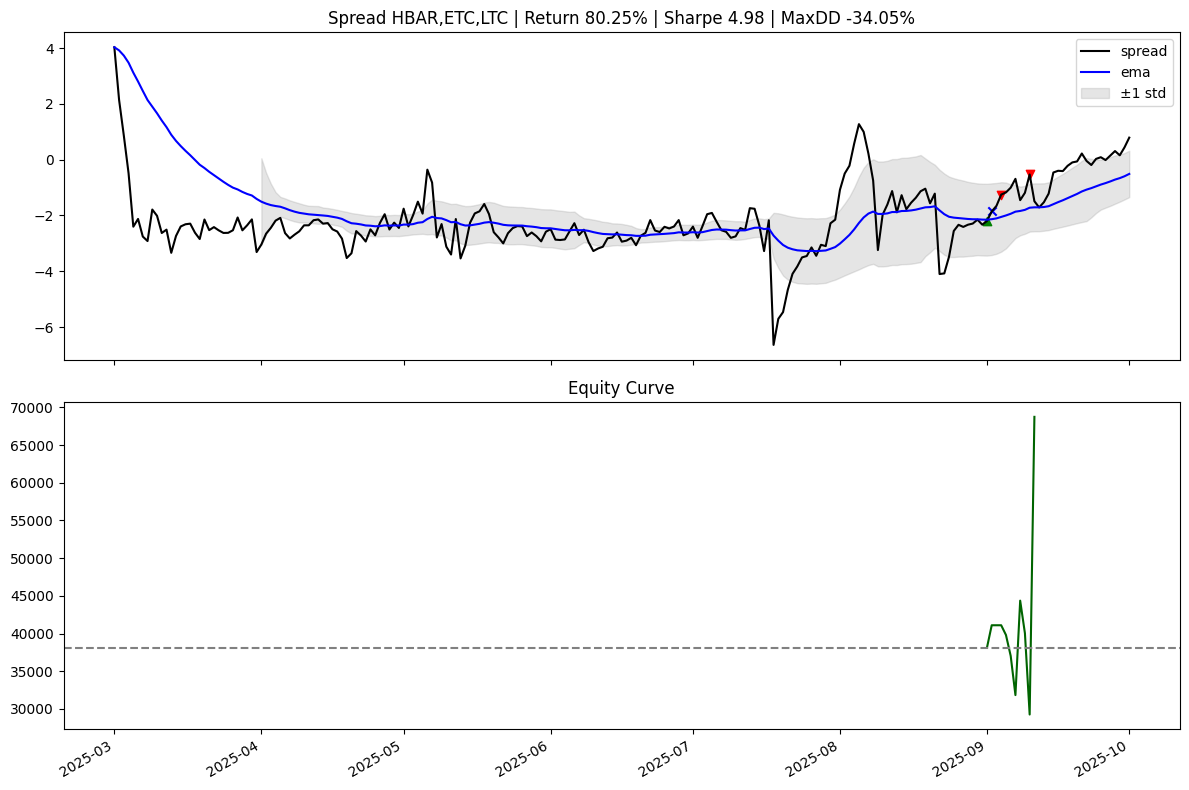

position remained open at month end. Waiting until it closes before reselection
  Spread HBAR,ETC,LTC: Half-life=2.14, Lookback=32, EMA=-0.4144, STD=0.8303
Capital depleted (<=0) on 2025-09-11; stopping trading for this spread.
  Spread HBAR,ETC,LTC: Half-life=2.14, Lookback=32, EMA=-0.3055, STD=0.8422
Capital depleted (<=0) on 2025-09-11; stopping trading for this spread.
  Spread HBAR,ETC,LTC: Half-life=2.14, Lookback=32, EMA=-0.1703, STD=0.9001
Capital depleted (<=0) on 2025-09-11; stopping trading for this spread.
  Spread HBAR,ETC,LTC: Half-life=2.14, Lookback=32, EMA=-0.0621, STD=0.9286
Capital depleted (<=0) on 2025-09-11; stopping trading for this spread.
  Spread HBAR,ETC,LTC: Half-life=2.14, Lookback=32, EMA=-0.0021, STD=0.9303
Capital depleted (<=0) on 2025-09-11; stopping trading for this spread.
  Spread HBAR,ETC,LTC: Half-life=2.14, Lookback=32, EMA=0.1081, STD=0.9732
Capital depleted (<=0) on 2025-09-11; stopping trading for this spread.
  Spread HBAR,ETC,LTC: Half-life=

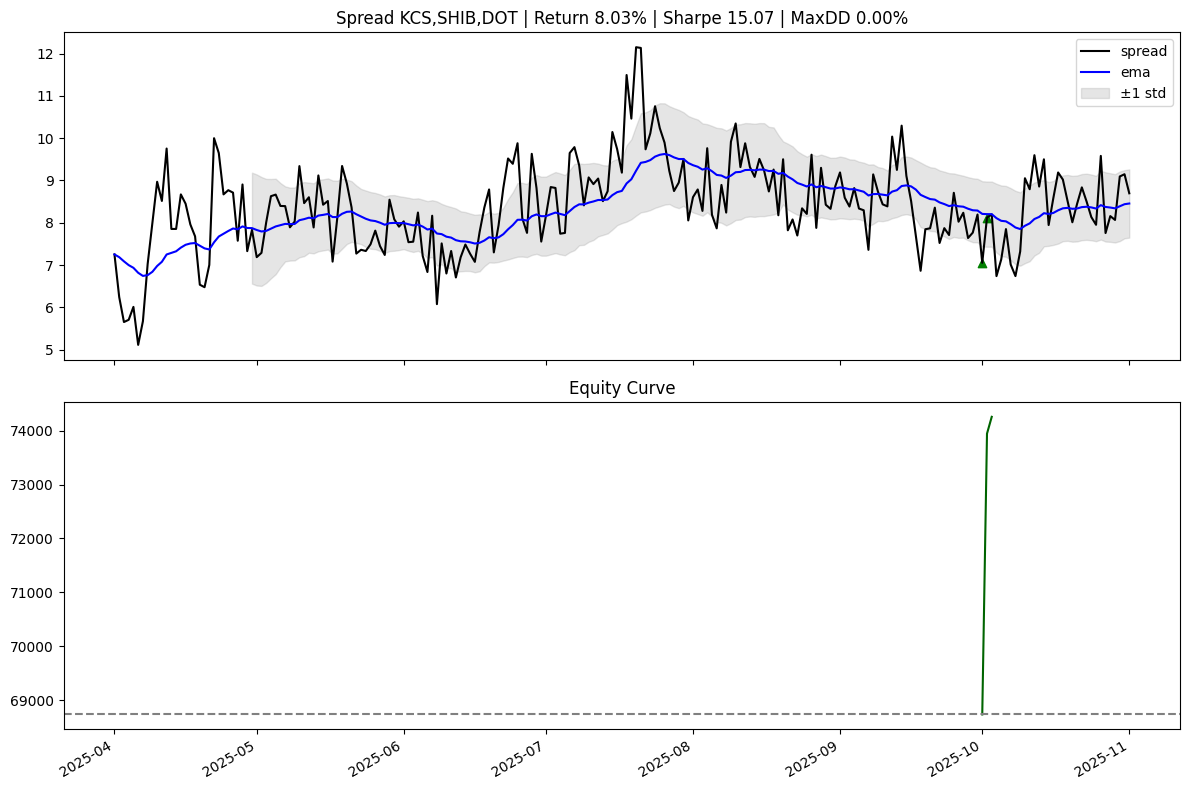

position remained open at month end. Waiting until it closes before reselection
  Spread KCS,SHIB,DOT: Half-life=1.77, Lookback=30, EMA=8.4629, STD=0.8081
Capital depleted (<=0) on 2025-10-03; stopping trading for this spread.
  Spread KCS,SHIB,DOT: Half-life=1.77, Lookback=30, EMA=8.4618, STD=0.7477
Capital depleted (<=0) on 2025-10-03; stopping trading for this spread.
  Spread KCS,SHIB,DOT: Half-life=1.77, Lookback=30, EMA=8.4728, STD=0.7079
Capital depleted (<=0) on 2025-10-03; stopping trading for this spread.
  Spread KCS,SHIB,DOT: Half-life=1.77, Lookback=30, EMA=8.4395, STD=0.7049
Capital depleted (<=0) on 2025-10-03; stopping trading for this spread.
  Spread KCS,SHIB,DOT: Half-life=1.77, Lookback=30, EMA=8.4055, STD=0.6582
Capital depleted (<=0) on 2025-10-03; stopping trading for this spread.
  Spread KCS,SHIB,DOT: Half-life=1.77, Lookback=30, EMA=8.3121, STD=0.6388
Capital depleted (<=0) on 2025-10-03; stopping trading for this spread.
  Spread KCS,SHIB,DOT: Half-life=1.77,

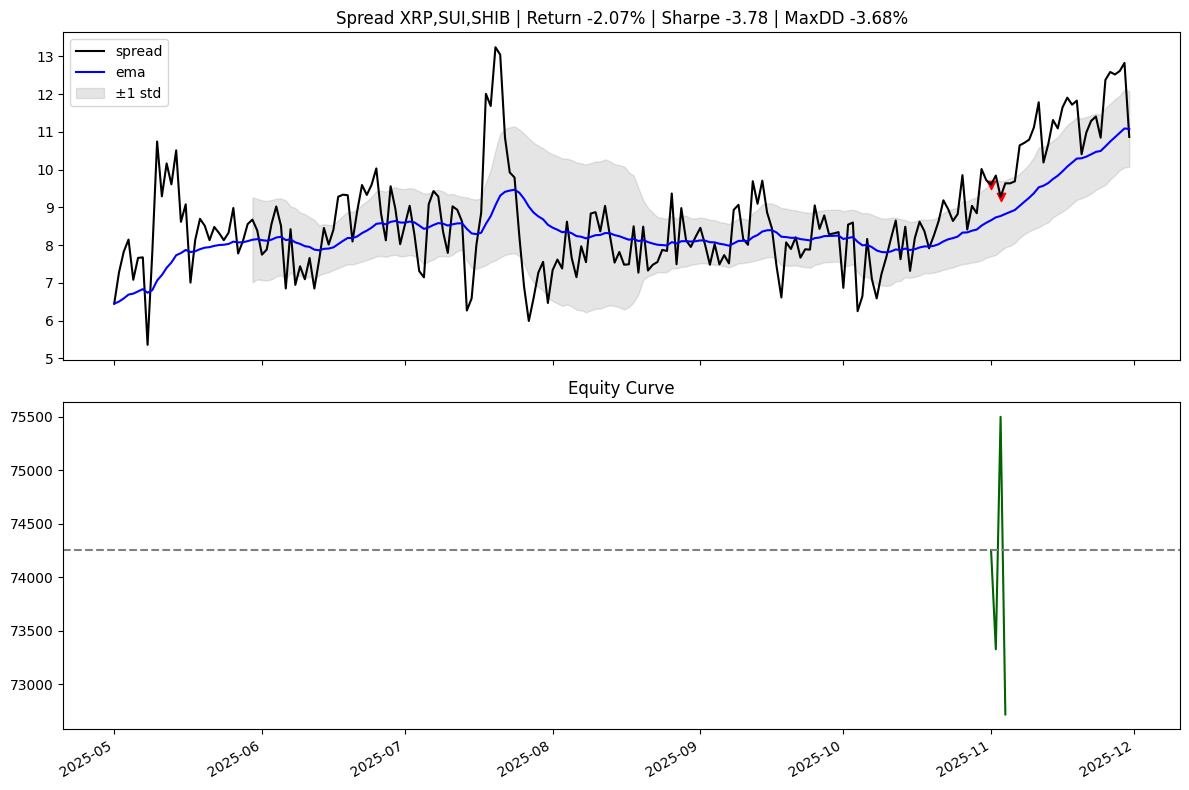

position remained open at month end. Waiting until it closes before reselection
  Spread XRP,SUI,SHIB: Half-life=1.51, Lookback=30, EMA=11.0760, STD=1.0015
Capital depleted (<=0) on 2025-11-04; stopping trading for this spread.
  Spread XRP,SUI,SHIB: Half-life=1.51, Lookback=30, EMA=11.0760, STD=1.0015
Capital depleted (<=0) on 2025-11-04; stopping trading for this spread.
  Spread XRP,SUI,SHIB: Half-life=1.51, Lookback=30, EMA=11.0760, STD=1.0015
Capital depleted (<=0) on 2025-11-04; stopping trading for this spread.
  Spread XRP,SUI,SHIB: Half-life=1.51, Lookback=30, EMA=11.0760, STD=1.0015
Capital depleted (<=0) on 2025-11-04; stopping trading for this spread.
  Spread XRP,SUI,SHIB: Half-life=1.51, Lookback=30, EMA=11.0760, STD=1.0015
Capital depleted (<=0) on 2025-11-04; stopping trading for this spread.
  Spread XRP,SUI,SHIB: Half-life=1.51, Lookback=30, EMA=11.0760, STD=1.0015
Capital depleted (<=0) on 2025-11-04; stopping trading for this spread.
  Spread XRP,SUI,SHIB: Half-life

In [218]:
wf_results = run_new_strategy(start='2025-01-01', end='2025-12-01', data_dir=DATA_SAVE_DIR, initial_capital=INITIAL_CAPITAL, plot=True)


In [219]:
final_capital = wf_results[-1]['backtest']['final_capital'] if wf_results else INITIAL_CAPITAL
get_report(wf_results, '2025-01-01', '2025-12-01', INITIAL_CAPITAL, final_capital)


Period: 2025-01-01 to 2025-12-01
Initial Capital: $10000.00
Final Capital: $72719.77
Total Return: 627.20%
Number of Selection Periods: 11
Total Trades: 83
Overall Sharpe Ratio: 3.4942
Overall Max Drawdown: -50.71%
PERIOD-BY-PERIOD BREAKDOWN
Period                  Combination                               Trades   Return %    Final Cap
--------------------------------------------------------------------------------
2025-01-01 to 2025-02-01 ENA, SHIB, NEAR                                4       8.65 $   10865.11
2025-02-01 to 2025-03-01 XRP, LINK, BTC                                 2      -4.22 $   10406.38
2025-03-01 to 2025-04-01 ETC, UNI, SHIB                                 2      21.88 $   12682.85
2025-04-01 to 2025-05-01 WLD, ICP, SHIB                                 2       9.42 $   13877.26
2025-05-01 to 2025-06-01 LTC, SHIB, DOT                                11     134.24 $   32506.43
2025-06-01 to 2025-07-01 HBAR, AVAX, SHIB                               4     -44.52 $   1

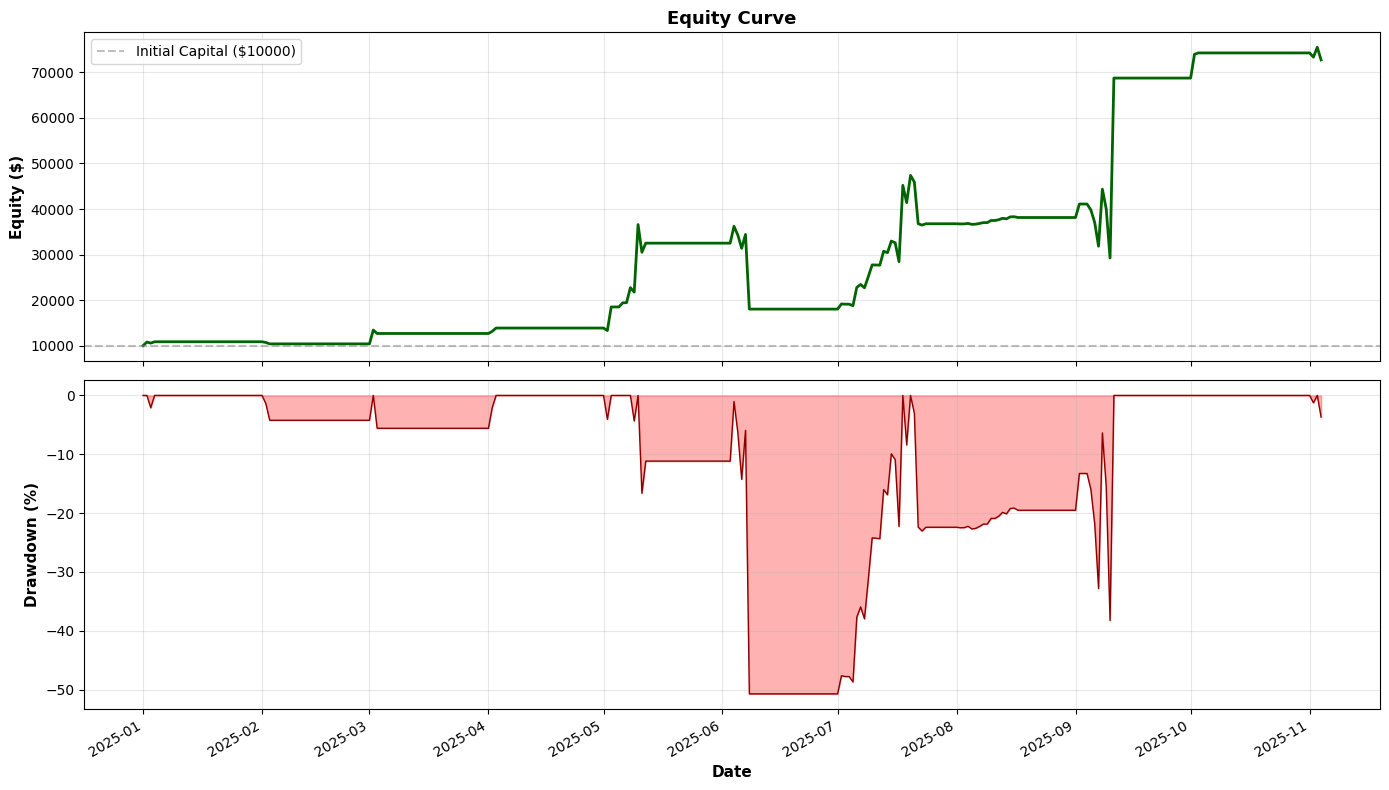

Final Equity: $72719.77
Total Return: 627.20%
Final Sharpe Ratio: 3.4942


In [220]:
all_equity_points = []
for r in wf_results:
    eq_df = r['backtest'].get('equity_df')
    if eq_df is not None and not eq_df.empty:
        for date, row in eq_df.iterrows():
            all_equity_points.append({'date': date, 'equity': row['equity']})

if all_equity_points:
    equity_full = pd.DataFrame(all_equity_points)
    equity_full = equity_full.sort_values('date').drop_duplicates(subset='date', keep='last')
    equity_full.set_index('date', inplace=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    ax1.plot(equity_full.index, equity_full['equity'], linewidth=2, color='darkgreen')
    ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle='--', alpha=0.5, label=f'Initial Capital (${INITIAL_CAPITAL})')
    ax1.set_ylabel('Equity ($)', fontsize=11, fontweight='bold')
    ax1.set_title('Equity Curve', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    equity_full['cummax'] = equity_full['equity'].cummax()
    equity_full['drawdown'] = (equity_full['equity'] - equity_full['cummax']) / equity_full['cummax'] * 100
    ax2.fill_between(equity_full.index, equity_full['drawdown'], 0, alpha=0.3, color='red')
    ax2.plot(equity_full.index, equity_full['drawdown'], linewidth=1, color='darkred')
    ax2.set_ylabel('Drawdown (%)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    
    equity_full['returns'] = equity_full['equity'].pct_change()
    daily_returns = equity_full['returns'].dropna()
    
    if len(daily_returns) > 1:
        mean_ret = daily_returns.mean()
        std_ret = daily_returns.std()
        daily_rf = RISK_FREE_RATE / 365
        final_sharpe = ((mean_ret - daily_rf) / std_ret) * np.sqrt(365) if std_ret > 0 else 0
    else:
        final_sharpe = 0.0

    print(f"Final Equity: ${final_capital:.2f}")
    print(f"Total Return: {((final_capital - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100):.2f}%")
    print(f"Final Sharpe Ratio: {final_sharpe:.4f}")
